## SETTING UP ENVIRONMENT & IMPORTING LIBRARIES & DATASET

### Environment Setup

In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [ ]:
!nvidia-smi

Thu Aug 20 13:38:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Importing Libraries

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

print("Libraries imported successfully.")

Libraries imported successfully.


### Setting Seed Value

In [ ]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed:", SEED)

Random seed: 42


In [ ]:
environment_info = {
    "Python": f"{__import__('sys').version}",
    "TensorFlow": tf.__version__,
    "NumPy": np.__version__,
    "Pandas": pd.__version__,
    "Random Seed": SEED
}

environment_df = pd.DataFrame(
    environment_info.items(),
    columns=["Parameter", "Value"]
)

environment_df

,Parameter,Value
0,Python,"3.12.13 (main, Mar 4 2026, 09:23:07) [GCC 11...."
1,TensorFlow,2.20.0
2,NumPy,2.0.2
3,Pandas,2.3.3
4,Random Seed,42


### Downloading Dataset

In [ ]:
!pip install -q kaggle

In [ ]:
import os
from getpass import getpass

os.environ["KAGGLE_API_TOKEN"] = getpass("Enter your Kaggle API token: ") #KGAT_12b219f8e6aec19eaba8cf544cccd670

Enter your Kaggle API token:  ········


In [ ]:
!kaggle datasets list -s CIFAKE

ref                                                         title                                                  size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------  ----------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
birdy654/cifake-real-and-ai-generated-synthetic-images      CIFAKE: Real and AI-Generated Synthetic Images    109625224  2023-03-28 16:00:29.500000          41546        242  0.875            
mariammarioma/midjourney-cifake-inspired                    Midjourney CIFAKE-Inspired                       2983770220  2024-04-14 18:50:52.243000            292          6  0.6875           
emanafi/cifake-texture-contrast-processed-dataset           CIFAKE Texture Contrast Processed Dataset        2435808105  2026-01-19 04:26:49                    17         12  0.9375           
superpotato9/dalle-recognition-data

In [ ]:
!kaggle datasets download -d birdy654/cifake-real-and-ai-generated-synthetic-images

Dataset URL: https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
License(s): other
100%|█████████████████████████████████████████| 105M/105M [00:00<00:00, 193MB/s]



#### Extracting Dataset

In [ ]:
!mkdir -p /kaggle/working/

!unzip -q \
    cifake-real-and-ai-generated-synthetic-images.zip \
    -d /kaggle/working/cifake

#### Analysing Folder Structure

In [ ]:
!find /kaggle/working/cifake -maxdepth 3 -type d

/kaggle/working/cifake
/kaggle/working/cifake/test
/kaggle/working/cifake/test/REAL
/kaggle/working/cifake/test/FAKE
/kaggle/working/cifake/train
/kaggle/working/cifake/train/REAL
/kaggle/working/cifake/train/FAKE


In [ ]:
!find /kaggle/working/cifake -maxdepth 3 -type f | head -20

/kaggle/working/cifake/test/REAL/0411.jpg
/kaggle/working/cifake/test/REAL/0411 (9).jpg
/kaggle/working/cifake/test/REAL/0585 (9).jpg
/kaggle/working/cifake/test/REAL/0748 (7).jpg
/kaggle/working/cifake/test/REAL/0314 (4).jpg
/kaggle/working/cifake/test/REAL/0737 (7).jpg
/kaggle/working/cifake/test/REAL/0918 (8).jpg
/kaggle/working/cifake/test/REAL/0549 (8).jpg
/kaggle/working/cifake/test/REAL/0515 (8).jpg
/kaggle/working/cifake/test/REAL/0309 (3).jpg
/kaggle/working/cifake/test/REAL/0043 (9).jpg
/kaggle/working/cifake/test/REAL/0638 (2).jpg
/kaggle/working/cifake/test/REAL/0425 (7).jpg
/kaggle/working/cifake/test/REAL/0459 (3).jpg
/kaggle/working/cifake/test/REAL/0819 (9).jpg
/kaggle/working/cifake/test/REAL/0388 (8).jpg
/kaggle/working/cifake/test/REAL/0899 (10).jpg
/kaggle/working/cifake/test/REAL/0123 (5).jpg
/kaggle/working/cifake/test/REAL/0005 (3).jpg
/kaggle/working/cifake/test/REAL/0584 (2).jpg
find: ‘standard output’: Broken pipe
find: write error


#### Total Images

In [ ]:
from pathlib import Path

dataset_path = Path("/kaggle/working/cifake")

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

image_files = [
    path for path in dataset_path.rglob("*")
    if path.is_file() and path.suffix.lower() in image_extensions
]

print("Total image files:", len(image_files))

Total image files: 120000


#### Creating Metadata DataFrame

In [ ]:
records = []

for image_path in image_files:

    path_lower = str(image_path).lower()

    if "real" in path_lower:
        label = 0
        class_name = "Real"

    elif "fake" in path_lower:
        label = 1
        class_name = "AI-Generated"

    else:
        continue

    records.append({
        "filepath": str(image_path),
        "label": label,
        "class_name": class_name
    })

df = pd.DataFrame(records)

print("Dataset shape:", df.shape)

Dataset shape: (120000, 3)


In [ ]:
df.head()

,filepath,label,class_name
0,/kaggle/working/cifake/test/REAL/0411.jpg,0,Real
1,/kaggle/working/cifake/test/REAL/0411 (9).jpg,0,Real
2,/kaggle/working/cifake/test/REAL/0585 (9).jpg,0,Real
3,/kaggle/working/cifake/test/REAL/0748 (7).jpg,0,Real
4,/kaggle/working/cifake/test/REAL/0314 (4).jpg,0,Real


## **DATA CLEANING**

### Checking Class Distribution

In [ ]:
class_counts = df["class_name"].value_counts()

print(class_counts)

class_name
Real            60000
AI-Generated    60000
Name: count, dtype: int64


In [ ]:
class_percentages = (
    df["class_name"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(class_percentages)

class_name
Real            50.0
AI-Generated    50.0
Name: proportion, dtype: float64


In [ ]:
class_distribution = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages
})

class_distribution

,Count,Percentage
class_name,,
Real,60000,50.0
AI-Generated,60000,50.0


### Analysing Image Dimensions

In [ ]:
def get_image_info(path):

    try:
        with Image.open(path) as img:
            return img.size, img.mode

    except Exception:
        return None, None

In [ ]:
sample_paths = df["filepath"].tolist()

image_info = []

for path in sample_paths:

    size, mode = get_image_info(path)

    image_info.append({
        "filepath": path,
        "size": size,
        "mode": mode
    })

image_info_df = pd.DataFrame(image_info)

print("Image dimensions:")
print(image_info_df["size"].value_counts())

print("\nImage modes:")
print(image_info_df["mode"].value_counts())

Image dimensions:
size
(32, 32)    120000
Name: count, dtype: int64

Image modes:
mode
RGB    120000
Name: count, dtype: int64


### Checking for Corrupted Images

In [ ]:
def is_valid_image(path):

    try:
        with Image.open(path) as img:
            img.verify()

        return True

    except Exception:
        return False

In [ ]:
df["valid_image"] = df["filepath"].apply(is_valid_image)

print(df["valid_image"].value_counts())

valid_image
True    120000
Name: count, dtype: int64


### Checking for Image Extension & Duplicate Images

In [ ]:
from collections import Counter

extensions = Counter(
    Path(path).suffix.lower()
    for path in df["filepath"]
)

extensions

Counter({'.jpg': 120000})

In [ ]:
import hashlib

def calculate_md5(filepath):

    with open(filepath, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()
df["md5"] = df["filepath"].apply(calculate_md5)
duplicate_count = df["md5"].duplicated(keep=False).sum()

print("Images involved in exact duplicates:", duplicate_count)
unique_hashes = df["md5"].nunique()

print("Total images:", len(df))
print("Unique image hashes:", unique_hashes)
print("Duplicate images:", len(df) - unique_hashes)

Images involved in exact duplicates: 2672
Total images: 120000
Unique image hashes: 118664
Duplicate images: 1336


### Checking Train/Test Structure

In [ ]:
def get_dataset_split(filepath):
    path_parts = Path(filepath).parts

    if "train" in path_parts:
        return "Train"
    elif "test" in path_parts:
        return "Test"
    else:
        return "Unknown"

df["dataset_split"] = df["filepath"].apply(get_dataset_split)

print(df["dataset_split"].value_counts())

dataset_split
Train    100000
Test      20000
Name: count, dtype: int64


#### Verify Class × Split Distribution

In [ ]:
split_class_table = pd.crosstab(
    df["dataset_split"],
    df["class_name"]
)

split_class_table

class_name,AI-Generated,Real
dataset_split,,
Test,10000,10000
Train,50000,50000


### Checking for Duplicate Images

In [ ]:
duplicate_groups = (
    df.groupby("md5")
      .agg(
          file_count=("filepath", "count"),
          classes=("class_name", lambda x: ", ".join(sorted(x.unique()))),
          splits=("dataset_split", lambda x: ", ".join(sorted(x.unique())))
      )
      .reset_index()
)

duplicate_groups = duplicate_groups[
    duplicate_groups["file_count"] > 1
].copy()

print("Number of duplicate groups:", len(duplicate_groups))

Number of duplicate groups: 1336


In [ ]:
duplicate_groups["file_count"].value_counts().sort_index()

file_count
2    1336
Name: count, dtype: int64

In [ ]:
cross_class_duplicates = duplicate_groups[
    duplicate_groups["classes"].str.contains(",")
]

print(
    "Cross-class duplicate groups:",
    len(cross_class_duplicates)
)

Cross-class duplicate groups: 0


In [ ]:
train_test_duplicates = duplicate_groups[
    duplicate_groups["splits"].str.contains("Test") &
    duplicate_groups["splits"].str.contains("Train")
]

print(
    "Train-Test duplicate groups:",
    len(train_test_duplicates)
)

Train-Test duplicate groups: 378


In [ ]:
leakage_hashes = set(train_test_duplicates["md5"])

leakage_images = df[
    df["md5"].isin(leakage_hashes)
].copy()

leakage_class_counts = (
    leakage_images["class_name"]
    .value_counts()
)

leakage_class_counts

class_name
AI-Generated    756
Name: count, dtype: int64

In [ ]:
pd.crosstab(
    leakage_images["dataset_split"],
    leakage_images["class_name"]
)

class_name,AI-Generated
dataset_split,
Test,378
Train,378


In [ ]:
train_test_duplicates["file_count"].value_counts()

file_count
2    378
Name: count, dtype: int64

In [ ]:
leakage_records = []

for md5_hash in train_test_duplicates["md5"]:

    group = df[df["md5"] == md5_hash]

    train_row = group[group["dataset_split"] == "Train"].iloc[0]
    test_row = group[group["dataset_split"] == "Test"].iloc[0]

    leakage_records.append({
        "md5": md5_hash,
        "class_name": train_row["class_name"],
        "train_filepath": train_row["filepath"],
        "test_filepath": test_row["filepath"]
    })

leakage_df = pd.DataFrame(leakage_records)

print("Leakage pairs:", len(leakage_df))

Leakage pairs: 378


In [ ]:
label_consistency = []

for md5_hash in train_test_duplicates["md5"]:

    group = df[df["md5"] == md5_hash]

    unique_labels = group["label"].unique()

    label_consistency.append({
        "md5": md5_hash,
        "number_of_labels": len(unique_labels),
        "labels": list(unique_labels)
    })

label_consistency_df = pd.DataFrame(label_consistency)

label_consistency_df["number_of_labels"].value_counts()

number_of_labels
1    378
Name: count, dtype: int64

In [ ]:
same_split_duplicates = duplicate_groups[
    ~duplicate_groups["splits"].str.contains(",")
].copy()

print(
    "Duplicate groups occurring within a single split:",
    len(same_split_duplicates)
)

Duplicate groups occurring within a single split: 958


In [ ]:
train_only_duplicates = same_split_duplicates[
    same_split_duplicates["splits"] == "Train"
]

test_only_duplicates = same_split_duplicates[
    same_split_duplicates["splits"] == "Test"
]

print(
    "Train-only duplicate groups:",
    len(train_only_duplicates)
)

print(
    "Test-only duplicate groups:",
    len(test_only_duplicates)
)

Train-only duplicate groups: 920
Test-only duplicate groups: 38


In [ ]:
train_duplicate_hashes = set(train_only_duplicates["md5"])
test_duplicate_hashes = set(test_only_duplicates["md5"])

train_duplicate_images = df[
    df["md5"].isin(train_duplicate_hashes)
].copy()

test_duplicate_images = df[
    df["md5"].isin(test_duplicate_hashes)
].copy()

print("Train-only duplicate images by class:")
print(train_duplicate_images["class_name"].value_counts())

print("\nTest-only duplicate images by class:")
print(test_duplicate_images["class_name"].value_counts())

Train-only duplicate images by class:
class_name
AI-Generated    1840
Name: count, dtype: int64

Test-only duplicate images by class:
class_name
AI-Generated    76
Name: count, dtype: int64


In [ ]:
# Hashes that occur in both Train and Test
leakage_hashes = set(train_test_duplicates["md5"])

# Identify the training copies involved in leakage
train_leakage = df[
    (df["md5"].isin(leakage_hashes)) &
    (df["dataset_split"] == "Train")
].copy()

print("Training images excluded due to Train-Test leakage:",
      len(train_leakage))

Training images excluded due to Train-Test leakage: 378


In [ ]:
train_duplicate_hashes = set(train_only_duplicates["md5"])

train_same_split = df[
    (df["md5"].isin(train_duplicate_hashes)) &
    (df["dataset_split"] == "Train")
].copy()

print("Train images involved in same-split duplicates:",
      len(train_same_split))

Train images involved in same-split duplicates: 1840


In [ ]:
test_duplicate_hashes = set(test_only_duplicates["md5"])

test_same_split = df[
    (df["md5"].isin(test_duplicate_hashes)) &
    (df["dataset_split"] == "Test")
].copy()

print("Test images involved in same-split duplicates:",
      len(test_same_split))

Test images involved in same-split duplicates: 76


In [ ]:
df["include_in_clean_dataset"] = True
df.loc[
    (df["md5"].isin(leakage_hashes)) &
    (df["dataset_split"] == "Train"),
    "include_in_clean_dataset"
] = False

In [ ]:
train_mask = df["dataset_split"] == "Train"

train_duplicate_mask = (
    df.loc[train_mask]
      .duplicated(subset=["md5"], keep="first")
)

train_duplicate_indices = df.loc[train_mask].index[
    train_duplicate_mask
]

df.loc[
    train_duplicate_indices,
    "include_in_clean_dataset"
] = False

In [ ]:
test_mask = df["dataset_split"] == "Test"

test_duplicate_mask = (
    df.loc[test_mask]
      .duplicated(subset=["md5"], keep="first")
)

test_duplicate_indices = df.loc[test_mask].index[
    test_duplicate_mask
]

df.loc[
    test_duplicate_indices,
    "include_in_clean_dataset"
] = False

In [ ]:
clean_df = df[
    df["include_in_clean_dataset"]
].copy()

print("Original images:", len(df))
print("Cleaned images:", len(clean_df))
print("Excluded images:", len(df) - len(clean_df))

Original images: 120000
Cleaned images: 118664
Excluded images: 1336


In [ ]:
clean_split_counts = clean_df["dataset_split"].value_counts()

clean_split_counts

dataset_split
Train    98702
Test     19962
Name: count, dtype: int64

In [ ]:
pd.crosstab(
    clean_df["dataset_split"],
    clean_df["class_name"]
)

class_name,AI-Generated,Real
dataset_split,,
Test,9962,10000
Train,48702,50000


In [ ]:
clean_df.to_csv(
    "/kaggle/working/cifake_cleaned_metadata.csv",
    index=False
)

print("Cleaned metadata saved successfully.")

Cleaned metadata saved successfully.


In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
print("Total cleaned images:", len(clean_df))

print("\nDataset split:")
print(clean_df["dataset_split"].value_counts())

print("\nClass distribution:")
print(clean_df["class_name"].value_counts())

Total cleaned images: 118664

Dataset split:
dataset_split
Train    98702
Test     19962
Name: count, dtype: int64

Class distribution:
class_name
Real            60000
AI-Generated    58664
Name: count, dtype: int64


### TRAIN-VAL-TEST SPLIT

In [ ]:
development_df = clean_df[
    clean_df["dataset_split"] == "Train"
].copy()

test_df = clean_df[
    clean_df["dataset_split"] == "Test"
].copy()

print("Development dataset:", len(development_df))
print("Test dataset:", len(test_df))

Development dataset: 98702
Test dataset: 19962


In [ ]:
development_df["class_name"].value_counts()

class_name
Real            50000
AI-Generated    48702
Name: count, dtype: int64

In [ ]:
test_df["class_name"].value_counts()

class_name
Real            10000
AI-Generated     9962
Name: count, dtype: int64

#### Train & Validation Split

In [ ]:
stratify=development_df["label"]
train_df, validation_df = train_test_split(
    development_df,
    test_size=0.20,
    random_state=42,
    stratify=development_df["label"]
)

In [ ]:
# Reset Index
train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [ ]:
# Checking Sizes
print("Training images:", len(train_df))
print("Validation images:", len(validation_df))
print("Test images:", len(test_df))

Training images: 78961
Validation images: 19741
Test images: 19962


In [ ]:
# Check class- distribution
split_class_distribution = pd.DataFrame({
    "Train": train_df["class_name"].value_counts(),
    "Validation": validation_df["class_name"].value_counts(),
    "Test": test_df["class_name"].value_counts()
})

split_class_distribution

,Train,Validation,Test
class_name,,,
Real,40000,10000,10000
AI-Generated,38961,9741,9962


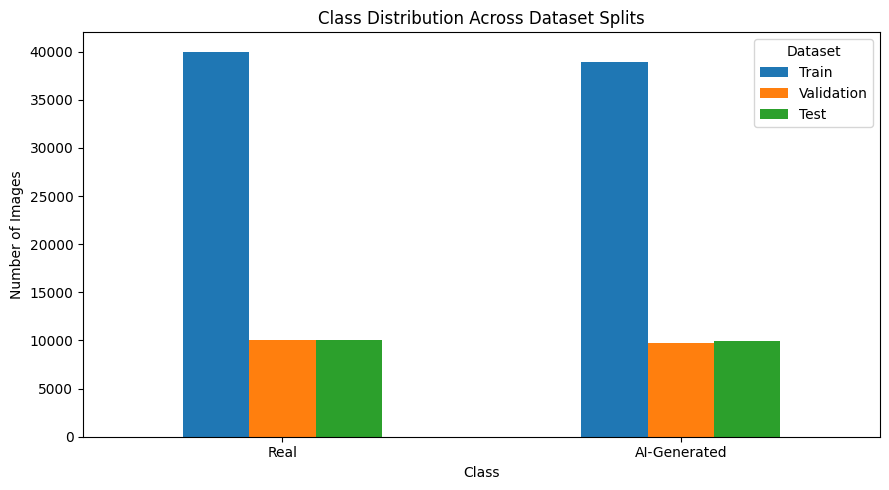

In [ ]:
# Vislualizing the split
import matplotlib.pyplot as plt

split_counts = pd.DataFrame({
    "Train": train_df["class_name"].value_counts(),
    "Validation": validation_df["class_name"].value_counts(),
    "Test": test_df["class_name"].value_counts()
})

split_counts.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Class Distribution Across Dataset Splits")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

In [ ]:
# Checking for Image repition
train_hashes = set(train_df["md5"])
validation_hashes = set(validation_df["md5"])
test_hashes = set(test_df["md5"])

In [ ]:
# Train Vs Validation
train_validation_overlap = train_hashes.intersection(
    validation_hashes
)

print(
    "Train-Validation exact duplicates:",
    len(train_validation_overlap)
)

Train-Validation exact duplicates: 0


In [ ]:
# Train Vs Test
train_test_overlap = train_hashes.intersection(
    test_hashes
)

print(
    "Train-Test exact duplicates:",
    len(train_test_overlap)
)

Train-Test exact duplicates: 0


In [ ]:
# Validation Vs Test
validation_test_overlap = validation_hashes.intersection(
    test_hashes
)

print(
    "Validation-Test exact duplicates:",
    len(validation_test_overlap)
)

Validation-Test exact duplicates: 0


In [ ]:
class_split_summary = pd.DataFrame({
    "Training": train_df["class_name"].value_counts(),
    "Validation": validation_df["class_name"].value_counts(),
    "Test": test_df["class_name"].value_counts()
}).fillna(0).astype(int)

class_split_summary

,Training,Validation,Test
class_name,,,
Real,40000,10000,10000
AI-Generated,38961,9741,9962


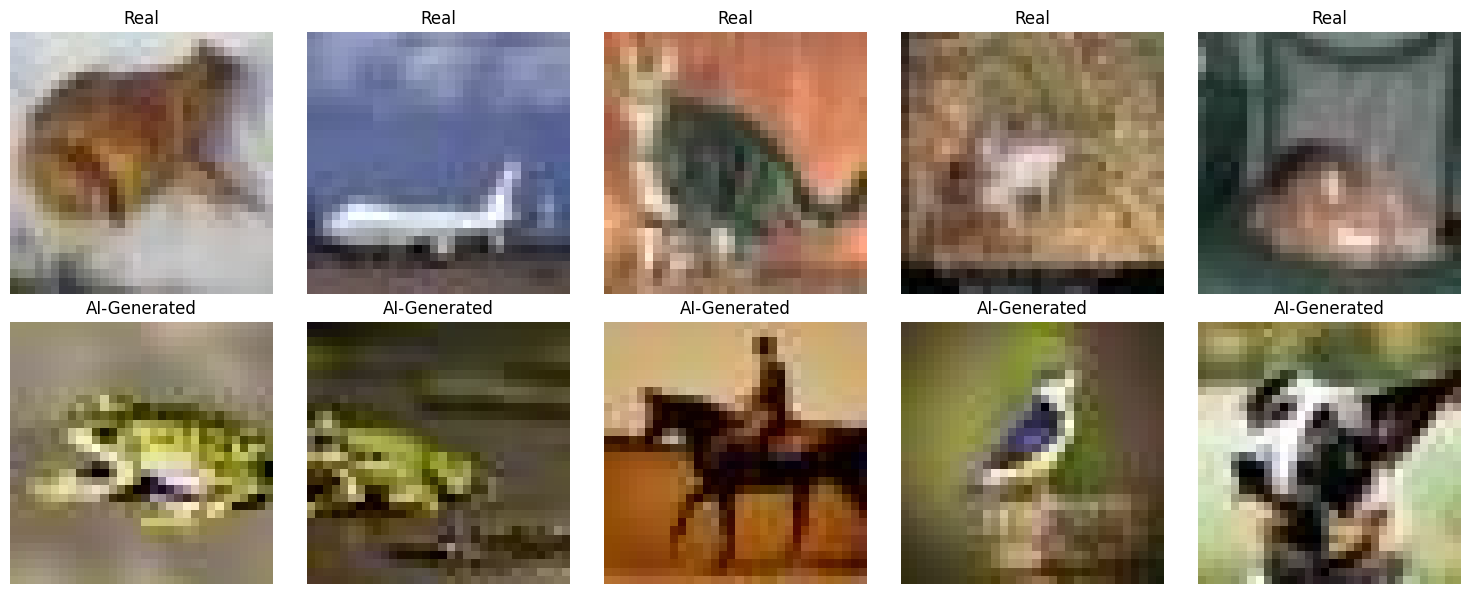

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

# Select a few random images
real_samples = train_df[
    train_df["class_name"] == "Real"
].sample(5, random_state=42)

fake_samples = train_df[
    train_df["class_name"] == "AI-Generated"
].sample(5, random_state=42)

samples = pd.concat([real_samples, fake_samples])

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, (_, row) in zip(axes.flat, samples.iterrows()):
    image = Image.open(row["filepath"]).convert("RGB")

    ax.imshow(image)
    ax.set_title(row["class_name"])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
sample_sizes = []

for filepath in train_df["filepath"].sample(1000, random_state=42):
    with Image.open(filepath) as img:
        sample_sizes.append(img.size)

from collections import Counter

Counter(sample_sizes)

Counter({(32, 32): 1000})

In [ ]:
sample_path = train_df.iloc[0]["filepath"]

sample_image = Image.open(sample_path).convert("RGB")

image_array = np.array(sample_image)

print("Shape:", image_array.shape)
print("Data type:", image_array.dtype)
print("Minimum pixel value:", image_array.min())
print("Maximum pixel value:", image_array.max())

Shape: (32, 32, 3)
Data type: uint8
Minimum pixel value: 7
Maximum pixel value: 192


#### Normalization

In [ ]:
normalized_image = image_array.astype("float32") / 255.0

print("Original range:")
print(image_array.min(), "to", image_array.max())

print("\nNormalized range:")
print(normalized_image.min(), "to", normalized_image.max())

print("\nShape:")
print(normalized_image.shape)

Original range:
7 to 192

Normalized range:
0.02745098 to 0.7529412

Shape:
(32, 32, 3)


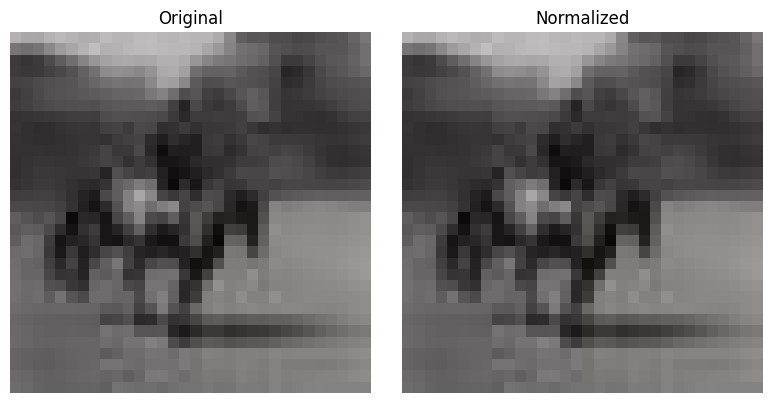

In [ ]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image_array)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(normalized_image)
plt.title("Normalized")
plt.axis("off")

plt.tight_layout()
plt.show()

#### Resizing the Image from 32 X 32 to 224 X 224

In [ ]:
resized_image = Image.open(
    sample_path
).convert("RGB").resize(
    (224, 224),
    Image.Resampling.BILINEAR
)

print("Original size:", Image.open(sample_path).size)
print("Resized size:", resized_image.size)

Original size: (32, 32)
Resized size: (224, 224)


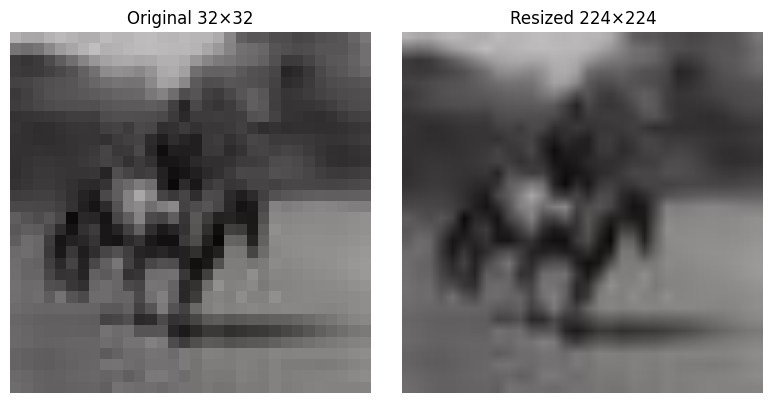

In [ ]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image_array)
plt.title("Original 32×32")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(resized_image)
plt.title("Resized 224×224")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
IMG_SIZE = (224, 224)

def preprocess_image(filepath):
    """
    Load and preprocess a CIFAKE image.

    Steps:
    1. Load image
    2. Convert to RGB
    3. Resize to 224x224
    4. Convert to float32
    5. Normalize pixel values to [0, 1]
    """

    image = Image.open(filepath).convert("RGB")

    image = image.resize(
        IMG_SIZE,
        Image.Resampling.BILINEAR
    )

    image = np.array(
        image,
        dtype=np.float32
    )

    image = image / 255.0

    return image

In [ ]:
processed_image = preprocess_image(
    train_df.iloc[0]["filepath"]
)

print("Shape:", processed_image.shape)
print("Data type:", processed_image.dtype)
print("Range:", processed_image.min(), "to", processed_image.max())

Shape: (224, 224, 3)
Data type: float32
Range: 0.02745098 to 0.7529412


### Data Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip(
        mode="horizontal"
    ),

    tf.keras.layers.RandomRotation(
        factor=0.014
    ),

    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    ),

    tf.keras.layers.RandomZoom(
        height_factor=0.10,
        width_factor=0.10
    )

], name="data_augmentation")

I0000 00:00:1787233217.078902      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787233217.082072      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [ ]:
data_augmentation.summary()

Model: "data_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ ?                      │   0 (unbuilt) │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
sample_path = train_df.iloc[0]["filepath"]

sample_image = Image.open(
    sample_path
).convert("RGB")

sample_array = np.array(
    sample_image,
    dtype=np.float32
) / 255.0

print("Original shape:", sample_array.shape)
print("Range:", sample_array.min(), "to", sample_array.max())

Original shape: (32, 32, 3)
Range: 0.02745098 to 0.7529412


In [ ]:
sample_resized = tf.image.resize(
    sample_array,
    (224, 224)
)

print("Resized shape:", sample_resized.shape)

Resized shape: (224, 224, 3)


In [ ]:
augmented_image = data_augmentation(
    tf.expand_dims(sample_resized, axis=0),
    training=True
)

augmented_image = augmented_image[0]

print("Augmented shape:", augmented_image.shape)
print(
    "Range:",
    float(tf.reduce_min(augmented_image)),
    "to",
    float(tf.reduce_max(augmented_image))
)

Augmented shape: (224, 224, 3)
Range: 0.04573596268892288 to 0.7446997761726379


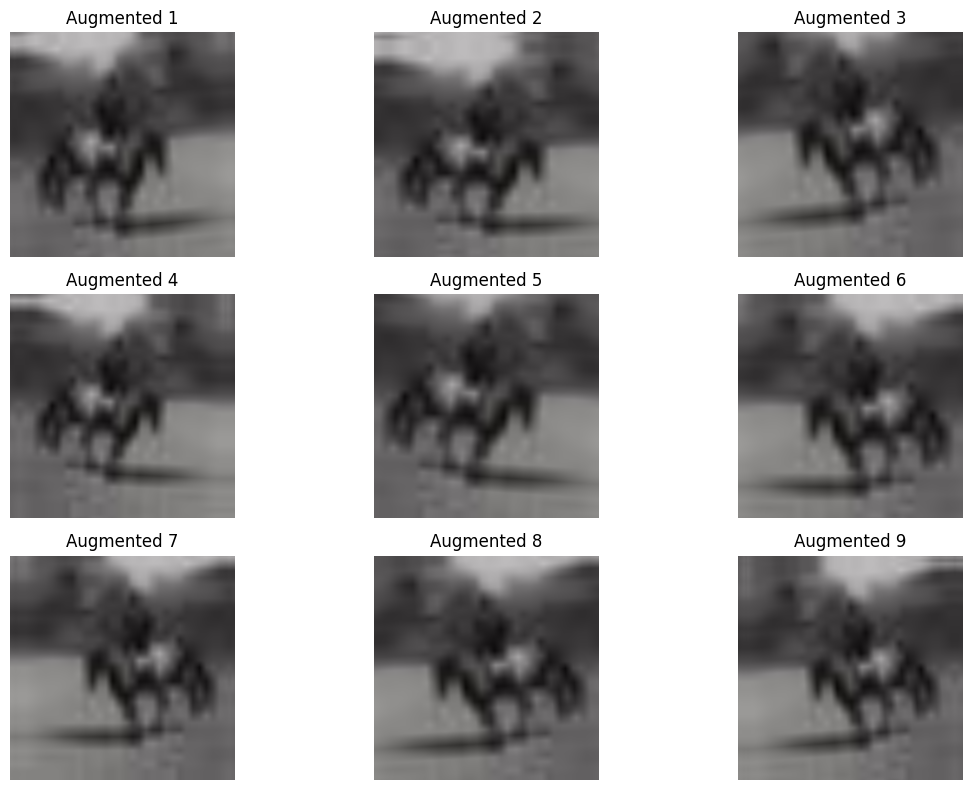

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(9):

    augmented = data_augmentation(
        tf.expand_dims(sample_resized, axis=0),
        training=True
    )[0]

    plt.subplot(3, 3, i + 1)
    plt.imshow(tf.clip_by_value(augmented, 0, 1))
    plt.title(f"Augmented {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

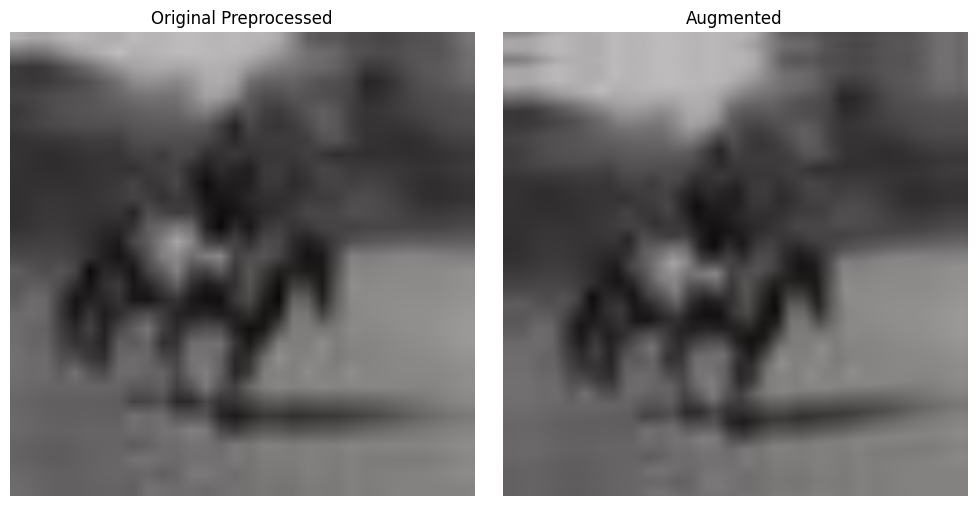

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)

plt.imshow(sample_resized)
plt.title("Original Preprocessed")
plt.axis("off")

plt.subplot(1, 2, 2)

plt.imshow(
    tf.clip_by_value(
        augmented_image,
        0,
        1
    )
)

plt.title("Augmented")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
assert augmented_image.shape == (224, 224, 3)

print("Augmented image shape:", augmented_image.shape)
print("Shape validation passed.")

Augmented image shape: (224, 224, 3)
Shape validation passed.


In [ ]:
aug_min = float(tf.reduce_min(augmented_image))
aug_max = float(tf.reduce_max(augmented_image))

print("Minimum:", aug_min)
print("Maximum:", aug_max)

Minimum: 0.04573596268892288
Maximum: 0.7446997761726379


In [ ]:
print("Training images:", len(train_df))
print("Validation images:", len(validation_df))
print("Test images:", len(test_df))

Training images: 78961
Validation images: 19741
Test images: 19962


### Tensorflow Pipeline

In [ ]:
print("Training:", len(train_df))
print("Validation:", len(validation_df))
print("Test:", len(test_df))

print("\nTraining classes:")
print(train_df["class_name"].value_counts())

print("\nValidation classes:")
print(validation_df["class_name"].value_counts())

print("\nTest classes:")
print(test_df["class_name"].value_counts())

Training: 78961
Validation: 19741
Test: 19962

Training classes:
class_name
Real            40000
AI-Generated    38961
Name: count, dtype: int64

Validation classes:
class_name
Real            10000
AI-Generated     9741
Name: count, dtype: int64

Test classes:
class_name
Real            10000
AI-Generated     9962
Name: count, dtype: int64


In [ ]:
required_columns = ["filepath", "class_name", "label"]

for column in required_columns:
    print(
        f"{column}:",
        column in train_df.columns
    )

filepath: True
class_name: True
label: True


In [ ]:
import tensorflow as tf
import numpy as np
import math

IMG_HEIGHT = 224
IMG_WIDTH = 224
CHANNELS = 3

BATCH_SIZE = 32
SEED = 42

AUTOTUNE = tf.data.AUTOTUNE

print("Image size:", IMG_HEIGHT, "x", IMG_WIDTH)
print("Channels:", CHANNELS)
print("Batch size:", BATCH_SIZE)
print("Seed:", SEED)

Image size: 224 x 224
Channels: 3
Batch size: 32
Seed: 42


In [ ]:
# Augmentation layer
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip(
        mode="horizontal",
        seed=SEED
    ),

    tf.keras.layers.RandomRotation(
        factor=0.014,
        seed=SEED
    ),

    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05,
        seed=SEED
    ),

    tf.keras.layers.RandomZoom(
        height_factor=0.10,
        width_factor=0.10,
        seed=SEED
    )

], name="data_augmentation")

In [ ]:
# Image Loading function
def load_and_preprocess_image(filepath, label, training=False):

    # Read image
    image = tf.io.read_file(filepath)

    # Decode JPG as RGB
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    # Convert uint8 [0,255] → float32 [0,1]
    image = tf.image.convert_image_dtype(
        image,
        tf.float32
    )

    # Resize
    image = tf.image.resize(
        image,
        [IMG_HEIGHT, IMG_WIDTH]
    )

    # Augmentation ONLY for training
    if training:
        image = data_augmentation(
            image,
            training=True
        )

    return image, label

In [ ]:
sample_path = train_df.iloc[0]["filepath"]
sample_label = train_df.iloc[0]["label"]

sample_tensor, sample_tensor_label = load_and_preprocess_image(
    tf.constant(sample_path),
    tf.constant(sample_label),
    training=False
)

print("Image shape:", sample_tensor.shape)
print("Image dtype:", sample_tensor.dtype)
print("Image minimum:", tf.reduce_min(sample_tensor).numpy())
print("Image maximum:", tf.reduce_max(sample_tensor).numpy())
print("Label:", sample_tensor_label.numpy())

Image shape: (224, 224, 3)
Image dtype: <dtype: 'float32'>
Image minimum: 0.019607844
Image maximum: 0.7490196
Label: 1


In [ ]:
augmented_tensor, augmented_label = load_and_preprocess_image(
    tf.constant(sample_path),
    tf.constant(sample_label),
    training=True
)

print("Augmented shape:", augmented_tensor.shape)
print("Augmented dtype:", augmented_tensor.dtype)
print("Augmented minimum:", tf.reduce_min(augmented_tensor).numpy())
print("Augmented maximum:", tf.reduce_max(augmented_tensor).numpy())
print("Label:", augmented_label.numpy())

Augmented shape: (224, 224, 3)
Augmented dtype: <dtype: 'float32'>
Augmented minimum: 0.036999594
Augmented maximum: 0.73916066
Label: 1


In [ ]:
# Creating Tensorflow training set
train_paths = train_df["filepath"].values
train_labels = train_df["label"].values.astype(np.int32)

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

print("Training dataset created.")

# Shuffling the training set
train_ds = train_ds.shuffle(
    buffer_size=len(train_df),
    seed=SEED,
    reshuffle_each_iteration=True
)

# Pre-processing & Augmentating the training set
train_ds = train_ds.map(
    lambda filepath, label:
        load_and_preprocess_image(
            filepath,
            label,
            training=True
        ),
    num_parallel_calls=AUTOTUNE
)



# Defining batches
train_ds = train_ds.batch(
    BATCH_SIZE,
    drop_remainder=False
)


# Using Prefatching to increase efficiency
train_ds = train_ds.prefetch(AUTOTUNE)

Training dataset created.


In [ ]:
# Defining Validation set
validation_paths = validation_df["filepath"].values
validation_labels = validation_df["label"].values.astype(np.int32)


# Shuffling
validation_ds = tf.data.Dataset.from_tensor_slices(
    (validation_paths, validation_labels)
)

# Pre-processing & Data Augmentation
validation_ds = validation_ds.map(
    lambda filepath, label:
        load_and_preprocess_image(
            filepath,
            label,
            training=False
        ),
    num_parallel_calls=AUTOTUNE
)

# Defining Batch Size
validation_ds = validation_ds.batch(
    BATCH_SIZE,
    drop_remainder=False
)


# Using Prefatching to increase efficiency
validation_ds = validation_ds.prefetch(AUTOTUNE)

In [ ]:
# Defining Test set
test_paths = test_df["filepath"].values
test_labels = test_df["label"].values.astype(np.int32)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

# Shuffling
test_ds = test_ds.map(
    lambda filepath, label:
        load_and_preprocess_image(
            filepath,
            label,
            training=False
        ),
    num_parallel_calls=AUTOTUNE
)

# Defining batches
test_ds = test_ds.batch(
    BATCH_SIZE,
    drop_remainder=False
)

# Using Prefatching
test_ds = test_ds.prefetch(
    AUTOTUNE
)

#### Inspection

In [ ]:
train_batch_images, train_batch_labels = next(
    iter(train_ds)
)

validation_batch_images, validation_batch_labels = next(
    iter(validation_ds)
)

test_batch_images, test_batch_labels = next(
    iter(test_ds)
)

print("TRAIN")
print("Image shape:", train_batch_images.shape)
print("Label shape:", train_batch_labels.shape)

print("\nVALIDATION")
print("Image shape:", validation_batch_images.shape)
print("Label shape:", validation_batch_labels.shape)

print("\nTEST")
print("Image shape:", test_batch_images.shape)
print("Label shape:", test_batch_labels.shape)

TRAIN
Image shape: (32, 224, 224, 3)
Label shape: (32,)

VALIDATION
Image shape: (32, 224, 224, 3)
Label shape: (32,)

TEST
Image shape: (32, 224, 224, 3)
Label shape: (32,)


In [ ]:
# Checking Image Range
print("Training image range:",
      float(tf.reduce_min(train_batch_images)),
      "to",
      float(tf.reduce_max(train_batch_images)))

print("Validation image range:",
      float(tf.reduce_min(validation_batch_images)),
      "to",
      float(tf.reduce_max(validation_batch_images)))

print("Test image range:",
      float(tf.reduce_min(test_batch_images)),
      "to",
      float(tf.reduce_max(test_batch_images)))

Training image range: 0.0 to 1.0
Validation image range: 0.0 to 1.0
Test image range: 0.0 to 1.0


In [ ]:
# Checking Labels
print("Training labels:",
      train_batch_labels.numpy())

print("\nValidation labels:",
      validation_batch_labels.numpy())

print("\nTest labels:",
      test_batch_labels.numpy())

Training labels: [1 0 1 0 0 1 0 1 0 1 1 0 0 0 0 1 1 1 0 1 0 1 0 0 0 0 0 1 1 0 1 0]

Validation labels: [1 1 0 1 0 0 1 0 0 1 1 1 0 1 0 1 0 1 1 1 1 1 0 0 1 1 0 1 0 1 1 0]

Test labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
print("Training labels:",
      train_batch_labels.numpy())

print("\nValidation labels:",
      validation_batch_labels.numpy())

print("\nTest labels:",
      test_batch_labels.numpy())

Training labels: [1 0 1 0 0 1 0 1 0 1 1 0 0 0 0 1 1 1 0 1 0 1 0 0 0 0 0 1 1 0 1 0]

Validation labels: [1 1 0 1 0 0 1 0 0 1 1 1 0 1 0 1 0 1 1 1 1 1 0 0 1 1 0 1 0 1 1 0]

Test labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
train_batches = math.ceil(
    len(train_df) / BATCH_SIZE
)

validation_batches = math.ceil(
    len(validation_df) / BATCH_SIZE
)

test_batches = math.ceil(
    len(test_df) / BATCH_SIZE
)

print("Training batches:", train_batches)
print("Validation batches:", validation_batches)
print("Test batches:", test_batches)

Training batches: 2468
Validation batches: 617
Test batches: 624


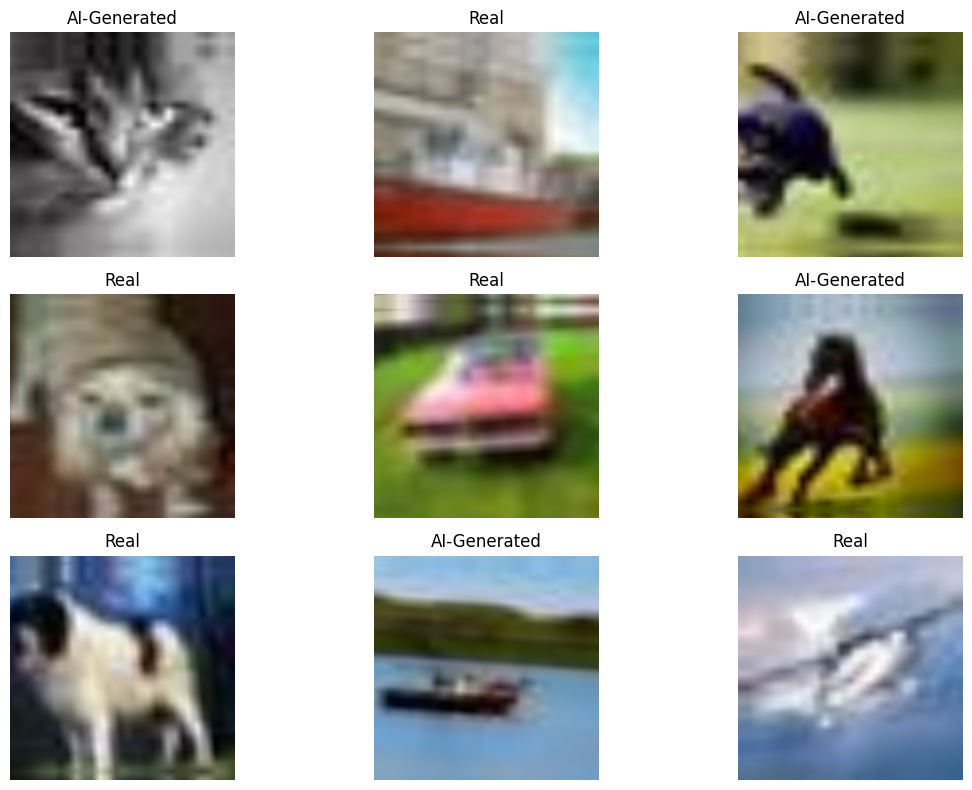

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    plt.imshow(
        tf.clip_by_value(
            train_batch_images[i],
            0,
            1
        )
    )

    label = train_batch_labels[i].numpy()

    class_name = (
        "Real"
        if label == 0
        else "AI-Generated"
    )

    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print("Expected training images:", len(train_df))
print("Expected validation images:", len(validation_df))
print("Expected test images:", len(test_df))

print("\nTotal expected images:",
      len(train_df) +
      len(validation_df) +
      len(test_df))

Expected training images: 78961
Expected validation images: 19741
Expected test images: 19962

Total expected images: 118664


In [ ]:
gpus = tf.config.list_physical_devices("GPU")

print("Available GPUs:")
print(gpus)

Available GPUs:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [ ]:
with tf.device("/GPU:0"):
    test_tensor = tf.random.normal(
        [1000, 1000]
    )

    result = tf.matmul(
        test_tensor,
        test_tensor
    )

print("GPU test completed.")

GPU test completed.


### BASELINE CNN

In [ ]:
# Defining the model
from tensorflow import keras
from tensorflow.keras import layers

baseline_cnn = keras.Sequential([

    # Input
    layers.Input(
        shape=(224, 224, 3)
    ),

    # Block 1
    layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Block 2
    layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Block 3
    layers.Conv2D(
        128,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Block 4
    layers.Conv2D(
        256,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Convert feature maps to a feature vector
    layers.GlobalAveragePooling2D(),

    # Classification head
    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(
        0.5
    ),

    # Binary classification
    layers.Dense(
        1,
        activation="sigmoid"
    )

], name="Baseline_CNN")

In [ ]:
baseline_cnn.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,441 (1.61 MB)

 Trainable params: 421,441 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Complining Model
baseline_cnn.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss=keras.losses.BinaryCrossentropy(),

    metrics=[
        keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),
        keras.metrics.Precision(
            name="precision"
        ),
        keras.metrics.Recall(
            name="recall"
        ),
        keras.metrics.AUC(
            name="auc"
        )
    ]
)

In [ ]:
print("Model:", baseline_cnn.name)
print("Optimizer:", baseline_cnn.optimizer.__class__.__name__)
print("Loss:", baseline_cnn.loss)
print("Metrics:", [m.name for m in baseline_cnn.metrics])

Model: Baseline_CNN
Optimizer: Adam
Loss: <LossFunctionWrapper(<function binary_crossentropy at 0x7a9d70e3b060>, kwargs={'from_logits': False, 'label_smoothing': 0.0, 'axis': -1})>
Metrics: ['loss', 'compile_metrics']


In [ ]:
import random
import numpy as np
import tensorflow as tf

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seeds set to:", SEED)

Random seeds set to: 42


In [ ]:
#Defining checkpoints
checkpoint_path = "/kaggle/working/baseline_cnn_best.keras"

callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
# Training CNN
EPOCHS = 10

history = baseline_cnn.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
   2/2468 ━━━━━━━━━━━━━━━━━━━━ 3:27 84ms/step - accuracy: 0.4375 - auc: 0.3837 - loss: 0.6981 - precision: 0.3810 - recall: 0.2713  

I0000 00:00:1786980309.790149     555 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2468/2468 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.7264 - auc: 0.8028 - loss: 0.5216 - precision: 0.7355 - recall: 0.6897
Epoch 1: val_loss improved from None to 0.42560, saving model to /kaggle/working/baseline_cnn_best.keras

Epoch 1: finished saving model to /kaggle/working/baseline_cnn_best.keras
2468/2468 ━━━━━━━━━━━━━━━━━━━━ 634s 252ms/step - accuracy: 0.7950 - auc: 0.8807 - loss: 0.4354 - precision: 0.7984 - recall: 0.7820 - val_accuracy: 0.8230 - val_auc: 0.9183 - val_loss: 0.4256 - val_precision: 0.7639 - val_recall: 0.9281 - learning_rate: 0.0010
Epoch 2/10
2468/2468 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.8679 - auc: 0.9387 - loss: 0.3174 - precision: 0.8647 - recall: 0.8686
Epoch 2: val_loss improved from 0.42560 to 0.21216, saving model to /kaggle/working/baseline_cnn_best.keras

Epoch 2: finished saving model to /kaggle/working/baseline_cnn_best.keras
2468/2468 ━━━━━━━━━━━━━━━━━━━━ 612s 248ms/step - accuracy: 0.8805 - auc: 0.9487 - loss: 0.2906 - precisio

In [ ]:
history_df = pd.DataFrame(history.history)

history_df

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
0,0.794987,0.880666,0.435356,0.798365,0.782013,0.822957,0.918306,0.425600,0.763856,0.928139,0.001
1,0.880523,0.948741,0.290643,0.877265,0.881138,0.918292,0.974468,0.212156,0.894716,0.945693,0.001
2,0.906447,0.966302,0.234452,0.902894,0.908062,0.930703,0.979834,0.180729,0.919111,0.942511,0.001
3,0.920214,0.974841,0.202410,0.916202,0.922692,0.929892,0.983286,0.174901,0.901818,0.962735,0.001
4,0.925508,0.976994,0.192859,0.921421,0.928185,0.933995,0.984396,0.173415,0.901657,0.972282,0.001
5,0.930333,0.979883,0.179516,0.925397,0.934114,0.945038,0.985899,0.148513,0.936027,0.953804,0.001
6,0.936196,0.982103,0.169172,0.932085,0.939119,0.920267,0.985969,0.198336,0.871666,0.983164,0.001
7,0.938932,0.983542,0.161818,0.935125,0.941557,0.948837,0.987829,0.136874,0.942165,0.954933,0.001
8,0.940135,0.984483,0.156578,0.935436,0.943816,0.950104,0.988026,0.136718,0.939823,0.960374,0.001
9,0.942554,0.985546,0.150996,0.938234,0.945843,0.945545,0.988167,0.141335,0.928162,0.964275,0.001


In [ ]:
best_epoch = (
    history_df["val_loss"].idxmin() + 1
)

best_val_loss = (
    history_df["val_loss"].min()
)

print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)

Best epoch: 9
Best validation loss: 0.13671815395355225


In [ ]:
best_accuracy_epoch = (
    history_df["val_accuracy"].idxmax() + 1
)

best_val_accuracy = (
    history_df["val_accuracy"].max()
)

print(
    "Best validation accuracy:",
    best_val_accuracy
)

print(
    "Achieved at epoch:",
    best_accuracy_epoch
)

Best validation accuracy: 0.9501038193702698
Achieved at epoch: 9


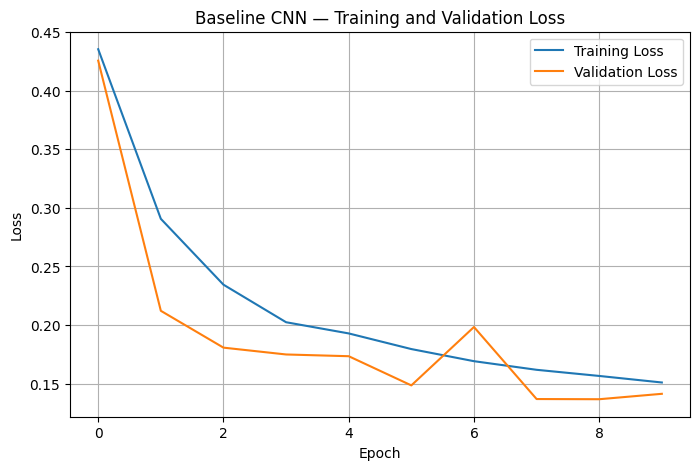

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN — Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

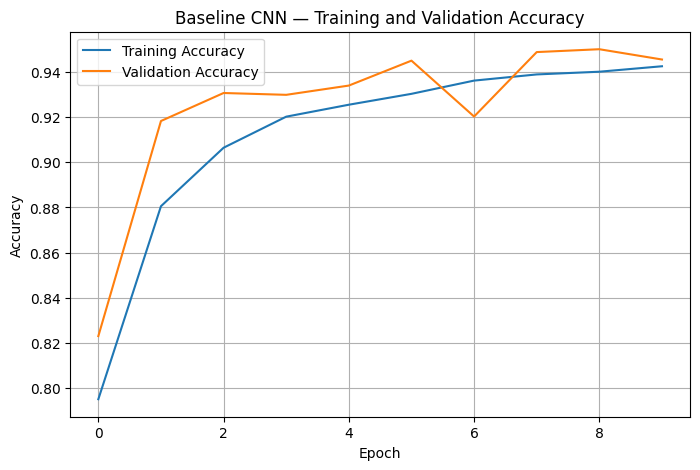

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN — Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

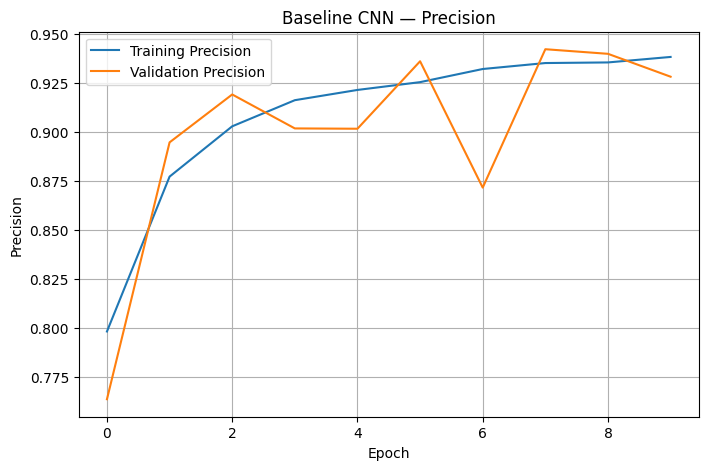

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["precision"],
    label="Training Precision"
)

plt.plot(
    history.history["val_precision"],
    label="Validation Precision"
)

plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Baseline CNN — Precision")
plt.legend()
plt.grid(True)
plt.show()

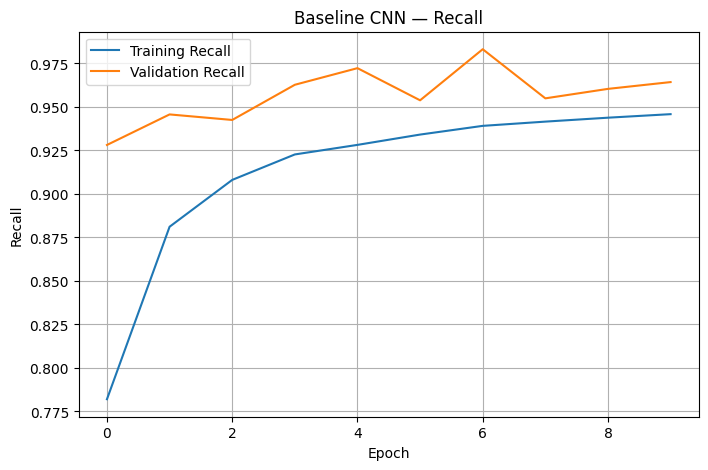

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["recall"],
    label="Training Recall"
)

plt.plot(
    history.history["val_recall"],
    label="Validation Recall"
)

plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Baseline CNN — Recall")
plt.legend()
plt.grid(True)
plt.show()

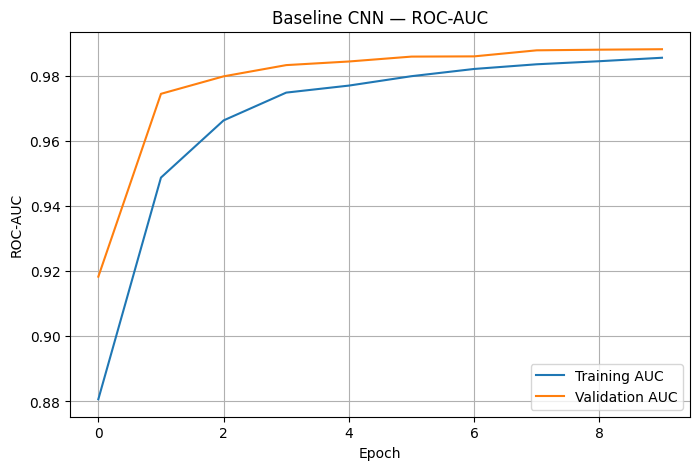

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["auc"],
    label="Training AUC"
)

plt.plot(
    history.history["val_auc"],
    label="Validation AUC"
)

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("Baseline CNN — ROC-AUC")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
best_baseline_cnn = keras.models.load_model(
    "/kaggle/working/baseline_cnn_best.keras"
)

print("Best Baseline CNN loaded successfully.")

Best Baseline CNN loaded successfully.


In [ ]:
validation_results = best_baseline_cnn.evaluate(
    validation_ds,
    return_dict=True,
    verbose=1
)

print("\nValidation Results:")

for metric, value in validation_results.items():
    print(f"{metric}: {value:.4f}")

617/617 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9501 - auc: 0.9880 - loss: 0.1367 - precision: 0.9398 - recall: 0.9604

Validation Results:
accuracy: 0.9501
auc: 0.9880
loss: 0.1367
precision: 0.9398
recall: 0.9604


In [ ]:
validation_probabilities = best_baseline_cnn.predict(
    validation_ds,
    verbose=1
).ravel()

validation_predictions = (
    validation_probabilities >= 0.5
).astype(int)

validation_true_labels = np.concatenate([
    labels.numpy()
    for _, labels in validation_ds
])

617/617 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        validation_true_labels,
        validation_predictions,
        target_names=[
            "Real",
            "AI-Generated"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

        Real     0.9606    0.9401    0.9502     10000
AI-Generated     0.9398    0.9604    0.9500      9741

    accuracy                         0.9501     19741
   macro avg     0.9502    0.9502    0.9501     19741
weighted avg     0.9503    0.9501    0.9501     19741



[[9401  599]
 [ 386 9355]]


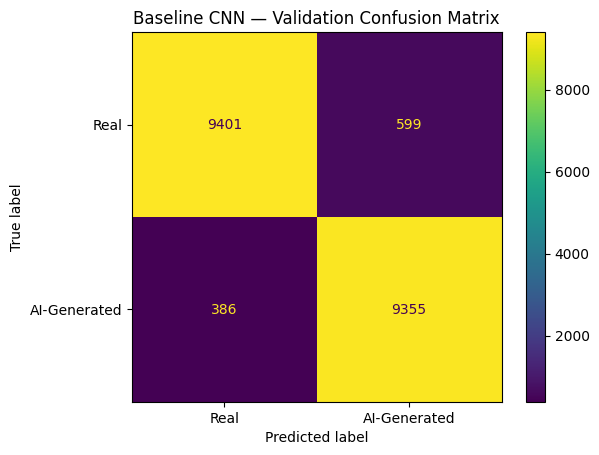

In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    validation_true_labels,
    validation_predictions
)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Real",
        "AI-Generated"
    ]
)

disp.plot()

plt.title(
    "Baseline CNN — Validation Confusion Matrix"
)

plt.show()

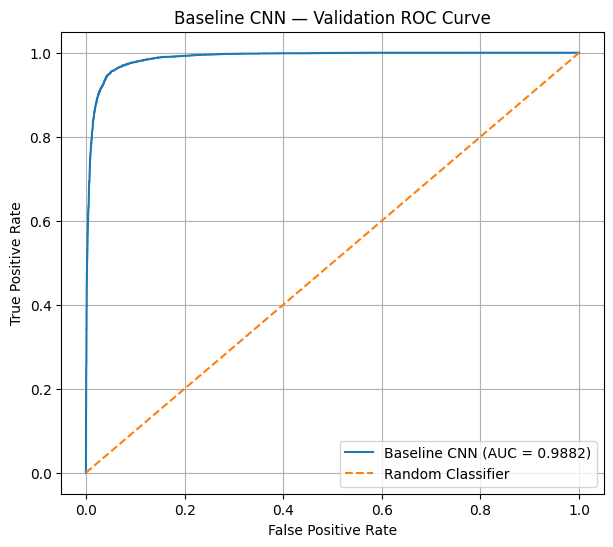

In [ ]:
# ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score

roc_auc = roc_auc_score(
    validation_true_labels,
    validation_probabilities
)

fpr, tpr, thresholds = roc_curve(
    validation_true_labels,
    validation_probabilities
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Baseline CNN (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline CNN — Validation ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

### ResNet50

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [ ]:
from tensorflow.keras.applications import ResNet50

In [ ]:
from tensorflow.keras.utils import register_keras_serializable

@register_keras_serializable()
class ResNetPreprocessing(tf.keras.layers.Layer):

    def call(self, inputs):
        # Convert [0, 1] → [0, 255]
        x = inputs * 255.0

        # ResNet50 ImageNet preprocessing
        return tf.keras.applications.resnet50.preprocess_input(x)

In [ ]:
from tensorflow.keras.applications import ResNet50

resnet_base = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

resnet_base.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Model Building
resnet_model = tf.keras.Sequential([

    tf.keras.layers.Input(
        shape=(224, 224, 3),
        name="input_image"
    ),

    ResNetPreprocessing(
        name="resnet_preprocessing"
    ),

    resnet_base,

    tf.keras.layers.GlobalAveragePooling2D(
        name="global_average_pooling"
    ),

    tf.keras.layers.Dense(
        256,
        activation="relu",
        name="classifier_dense"
    ),

    tf.keras.layers.Dropout(
        0.5,
        name="classifier_dropout"
    ),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid",
        name="output"
    )

], name="ResNet50_TransferLearning")

In [ ]:
resnet_model.summary()

Model: "ResNet50_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet_preprocessing            │ (None, 224, 224, 3)    │             0 │
│ (ResNetPreprocessing)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dense (Dense)        │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout (Dropout)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
total_params = resnet_model.count_params()

trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in resnet_model.trainable_weights
)

non_trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in resnet_model.non_trainable_weights
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)
print("Non-trainable parameters:", non_trainable_params)

Total parameters: 24112513
Trainable parameters: 524801
Non-trainable parameters: 23587712


In [ ]:
# Compiling Model
resnet_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss=keras.losses.BinaryCrossentropy(),

    metrics=[
        keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),
        keras.metrics.Precision(
            name="precision"
        ),
        keras.metrics.Recall(
            name="recall"
        ),
        keras.metrics.AUC(
            name="auc"
        )
    ]
)

In [ ]:
test_path = "/kaggle/working/resnet50_serialization_test.h5"

resnet_model.save(test_path)

print("Model saved successfully.")

test_loaded_model = tf.keras.models.load_model(
    test_path
)

print("Model loaded successfully.")

Model saved successfully.


Model loaded successfully.


In [ ]:
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss=tf.keras.losses.BinaryCrossentropy(),

    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        ),
        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)

In [ ]:
print("Model compiled successfully.")
print("Learning rate:", 1e-4)
print("Backbone trainable:", resnet_base.trainable)

Model compiled successfully.
Learning rate: 0.0001
Backbone trainable: False


In [ ]:
# Creating Callbacks
resnet_stage1_path = "/kaggle/working/resnet50_stage1_best.h5"

resnet_stage1_callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=resnet_stage1_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
resnet_stage1_history = resnet_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=10,
    callbacks=resnet_stage1_callbacks,
    verbose=1
)

Epoch 1/10
2468/2468 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.8402 - auc: 0.9162 - loss: 0.3501 - precision: 0.8356 - recall: 0.8397
Epoch 1: val_loss improved from None to 0.15244, saving model to /kaggle/working/resnet50_stage1_best.h5



Epoch 1: finished saving model to /kaggle/working/resnet50_stage1_best.h5
2468/2468 ━━━━━━━━━━━━━━━━━━━━ 699s 277ms/step - accuracy: 0.8907 - auc: 0.9597 - loss: 0.2574 - precision: 0.8874 - recall: 0.8915 - val_accuracy: 0.9409 - val_auc: 0.9865 - val_loss: 0.1524 - val_precision: 0.9286 - val_recall: 0.9536 - learning_rate: 1.0000e-04
Epoch 2/10
2468/2468 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.9326 - auc: 0.9820 - loss: 0.1719 - precision: 0.9300 - recall: 0.9333
Epoch 2: val_loss improved from 0.15244 to 0.12334, saving model to /kaggle/working/resnet50_stage1_best.h5



Epoch 2: finished saving model to /kaggle/working/resnet50_stage1_best.h5
2468/2468 ━━━━━━━━━━━━━━━━━━━━ 671s 272ms/step - accuracy: 0.9347 - auc: 0.9831 - loss: 0.1662 - precision: 0.9325 - recall: 0.9353 - val_accuracy: 0.9538 - val_auc: 0.9908 - val_loss: 0.1233 - val_precision: 0.9521 - val_recall: 0.9544 - learning_rate: 1.0000e-04
Epoch 3/10
 962/2468 ━━━━━━━━━━━━━━━━━━━━ 6:17 251ms/step - accuracy: 0.9443 - auc: 0.9871 - loss: 0.1458 - precision: 0.9429 - recall: 0.9443

In [ ]:
resnet_stage1_history_df = pd.DataFrame(
    resnet_stage1_history.history
)

resnet_stage1_history_df

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
0,0.950976,0.990239,0.125130,0.949112,0.951670,0.959425,0.993091,0.105551,0.957710,0.960168,0.0001
1,0.953990,0.991091,0.118621,0.951903,0.955006,0.959830,0.993596,0.105071,0.969563,0.948363,0.0001
2,0.957029,0.992153,0.111108,0.955883,0.957085,0.962261,0.994220,0.096704,0.962757,0.960682,0.0001
3,0.959588,0.993042,0.104948,0.957698,0.960525,0.960286,0.994315,0.100803,0.974669,0.944051,0.0001
4,0.961551,0.993463,0.100748,0.960991,0.961089,0.964490,0.994424,0.092399,0.962073,0.966123,0.0001
5,0.962614,0.993876,0.097798,0.961737,0.962527,0.963173,0.994576,0.093626,0.970361,0.954522,0.0001
6,0.964476,0.994436,0.093109,0.963753,0.964272,0.965351,0.994796,0.088773,0.963938,0.965917,0.0001
7,0.965261,0.994653,0.090353,0.964000,0.965658,0.966162,0.995041,0.088246,0.959858,0.972077,0.0001
8,0.966528,0.995121,0.086756,0.966429,0.965709,0.967074,0.994943,0.087386,0.962929,0.970640,0.0001
9,0.968909,0.995489,0.083063,0.969156,0.967788,0.967783,0.995192,0.086120,0.973479,0.960887,0.0001


In [ ]:
best_stage1_epoch = (
    resnet_stage1_history_df["val_loss"].idxmin() + 1
)

best_stage1_loss = (
    resnet_stage1_history_df["val_loss"].min()
)

print("Best Stage 1 epoch:", best_stage1_epoch)
print("Best Stage 1 validation loss:", best_stage1_loss)

Best Stage 1 epoch: 10
Best Stage 1 validation loss: 0.08612021803855896


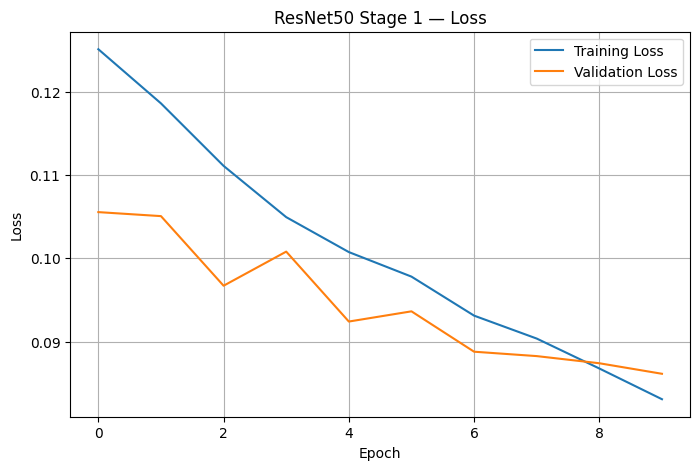

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    resnet_stage1_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    resnet_stage1_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Stage 1 — Loss")
plt.legend()
plt.grid(True)
plt.show()

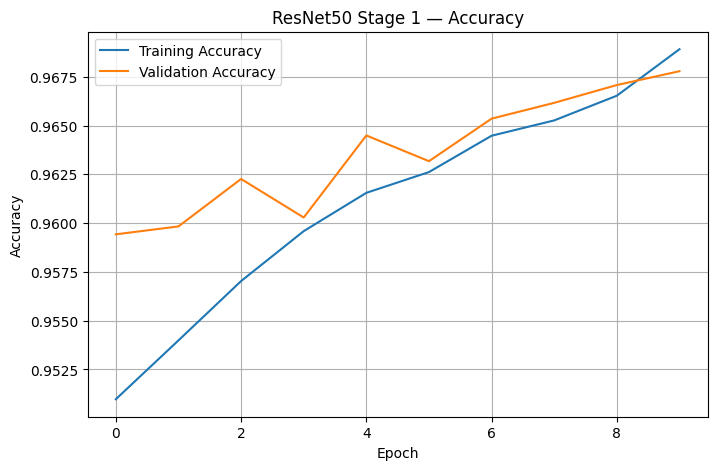

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    resnet_stage1_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    resnet_stage1_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Stage 1 — Accuracy")
plt.legend()
plt.grid(True)
plt.show()

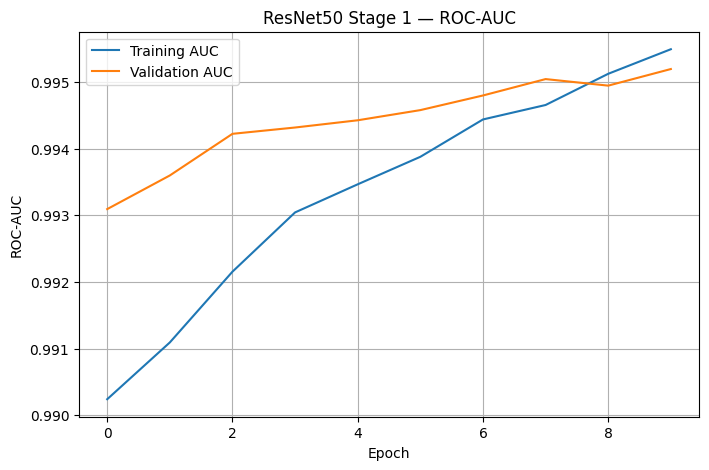

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    resnet_stage1_history.history["auc"],
    label="Training AUC"
)

plt.plot(
    resnet_stage1_history.history["val_auc"],
    label="Validation AUC"
)

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("ResNet50 Stage 1 — ROC-AUC")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
stage1_results = resnet_model.evaluate(
    validation_ds,
    return_dict=True,
    verbose=1
)

print("\nResNet50 Stage 1 Validation Results:")

for metric, value in stage1_results.items():
    print(
        f"{metric}: {value:.4f}"
    )

617/617 ━━━━━━━━━━━━━━━━━━━━ 58s 94ms/step - accuracy: 0.9678 - auc: 0.9952 - loss: 0.0861 - precision: 0.9735 - recall: 0.9609

ResNet50 Stage 1 Validation Results:
accuracy: 0.9678
auc: 0.9952
loss: 0.0861
precision: 0.9735
recall: 0.9609


#### Fine Tuning ResNet50 Model

In [ ]:
best_resnet_stage1 = tf.keras.models.load_model(
    resnet_stage1_path
)

print("Best Stage 1 ResNet50 loaded.")

Best Stage 1 ResNet50 loaded.


In [ ]:
for layer in best_resnet_stage1.layers:
    print(layer.name, type(layer).__name__)

resnet_preprocessing ResNetPreprocessing
resnet50 Functional
global_average_pooling GlobalAveragePooling2D
classifier_dense Dense
classifier_dropout Dropout
output Dense


In [ ]:
resnet_base = best_resnet_stage1.get_layer("resnet50")

print("ResNet backbone found.")
print("Number of layers:", len(resnet_base.layers))

ResNet backbone found.
Number of layers: 175


In [ ]:
fine_tune_from = 100

resnet_base.trainable = True

for layer in resnet_base.layers[:fine_tune_from]:
    layer.trainable = False

for layer in resnet_base.layers[fine_tune_from:]:
    layer.trainable = True

In [ ]:
for layer in resnet_base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

In [ ]:
trainable_resnet_layers = [
    layer.name
    for layer in resnet_base.layers
    if layer.trainable
]

print(
    "Total ResNet layers:",
    len(resnet_base.layers)
)

print(
    "Trainable ResNet layers:",
    len(trainable_resnet_layers)
)

print(
    "Trainable BatchNorm layers:",
    sum(
        1
        for layer in resnet_base.layers
        if isinstance(layer, tf.keras.layers.BatchNormalization)
        and layer.trainable
    )
)

Total ResNet layers: 175
Trainable ResNet layers: 52
Trainable BatchNorm layers: 0


In [ ]:
best_resnet_stage1.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss=tf.keras.losses.BinaryCrossentropy(),

    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        ),
        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)

In [ ]:
total_params = best_resnet_stage1.count_params()

trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in best_resnet_stage1.trainable_weights
)

non_trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in best_resnet_stage1.non_trainable_weights
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)
print("Non-trainable parameters:", non_trainable_params)

Total parameters: 24112513
Trainable parameters: 19940865
Non-trainable parameters: 4171648


In [ ]:
resnet_finetune_path = (
    "/kaggle/working/resnet50_finetuned_best.keras"
)

resnet_finetune_callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=resnet_finetune_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
resnet_finetune_history = best_resnet_stage1.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=10,
    callbacks=resnet_finetune_callbacks,
    verbose=1
)

Epoch 1/10
2468/2468 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.9674 - auc: 0.9948 - loss: 0.0879 - precision: 0.9668 - recall: 0.9673
Epoch 1: val_loss improved from None to 0.06448, saving model to /content/resnet50_finetuned_best.keras

Epoch 1: finished saving model to /content/resnet50_finetuned_best.keras
2468/2468 ━━━━━━━━━━━━━━━━━━━━ 931s 368ms/step - accuracy: 0.9710 - auc: 0.9958 - loss: 0.0784 - precision: 0.9703 - recall: 0.9710 - val_accuracy: 0.9762 - val_auc: 0.9973 - val_loss: 0.0645 - val_precision: 0.9708 - val_recall: 0.9813 - learning_rate: 1.0000e-05
Epoch 2/10
2468/2468 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.9792 - auc: 0.9978 - loss: 0.0550 - precision: 0.9792 - recall: 0.9784
Epoch 2: val_loss improved from 0.06448 to 0.06331, saving model to /content/resnet50_finetuned_best.keras

Epoch 2: finished saving model to /content/resnet50_finetuned_best.keras
2468/2468 ━━━━━━━━━━━━━━━━━━━━ 886s 359ms/step - accuracy: 0.9795 - auc: 0.9978 - loss: 0.0555

In [ ]:
best_resnet_finetuned = tf.keras.models.load_model(
    resnet_finetune_path
)

print("Best fine-tuned ResNet50 loaded successfully.")

Best fine-tuned ResNet50 loaded successfully.


In [ ]:
finetuned_results = best_resnet_finetuned.evaluate(
    validation_ds,
    return_dict=True,
    verbose=1
)

print("\nResNet50 Fine-Tuned Validation Results:")

for metric, value in finetuned_results.items():
    print(f"{metric}: {value:.4f}")

617/617 ━━━━━━━━━━━━━━━━━━━━ 67s 100ms/step - accuracy: 0.9817 - auc: 0.9976 - loss: 0.0523 - precision: 0.9814 - recall: 0.9814

ResNet50 Fine-Tuned Validation Results:
accuracy: 0.9817
auc: 0.9976
loss: 0.0523
precision: 0.9814
recall: 0.9814


In [ ]:
resnet_ft_probabilities = best_resnet_finetuned.predict(
    validation_ds,
    verbose=1
).ravel()

resnet_ft_predictions = (
    resnet_ft_probabilities >= 0.5
).astype(int)

resnet_ft_true_labels = np.concatenate([
    labels.numpy()
    for _, labels in validation_ds
])

print(
    "True labels:",
    resnet_ft_true_labels.shape
)

print(
    "Predictions:",
    resnet_ft_predictions.shape
)

617/617 ━━━━━━━━━━━━━━━━━━━━ 67s 101ms/step
True labels: (19741,)
Predictions: (19741,)


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        resnet_ft_true_labels,
        resnet_ft_predictions,
        target_names=[
            "Real",
            "AI-Generated"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

        Real     0.9819    0.9819    0.9819     10000
AI-Generated     0.9814    0.9814    0.9814      9741

    accuracy                         0.9817     19741
   macro avg     0.9817    0.9817    0.9817     19741
weighted avg     0.9817    0.9817    0.9817     19741



[[9819  181]
 [ 181 9560]]


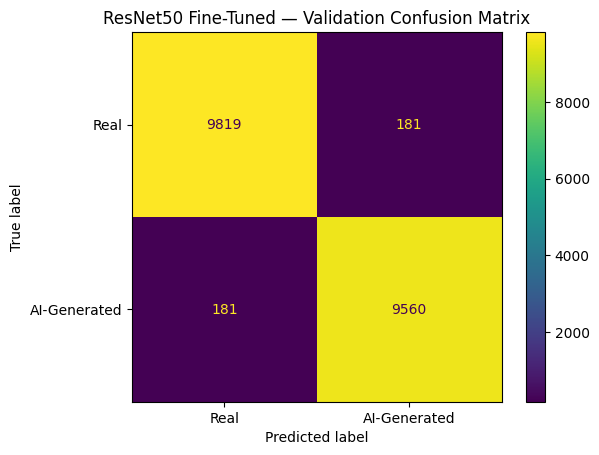

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

resnet_ft_cm = confusion_matrix(
    resnet_ft_true_labels,
    resnet_ft_predictions
)

print(resnet_ft_cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=resnet_ft_cm,
    display_labels=[
        "Real",
        "AI-Generated"
    ]
)

disp.plot()

plt.title(
    "ResNet50 Fine-Tuned — Validation Confusion Matrix"
)

plt.show()

In [ ]:
resnet_ft_metrics = {
    "Model": "ResNet50 Fine-Tuned",
    "Accuracy": finetuned_results["accuracy"],
    "Precision": finetuned_results["precision"],
    "Recall": finetuned_results["recall"],
    "ROC-AUC": finetuned_results["auc"],
    "Loss": finetuned_results["loss"],
    "Best_Epoch": 4,
    "Total_Parameters": best_resnet_finetuned.count_params()
}

resnet_ft_metrics_df = pd.DataFrame(
    [resnet_ft_metrics]
)

resnet_ft_metrics_df

,Model,Accuracy,Precision,Recall,ROC-AUC,Loss,Best_Epoch,Total_Parameters
0,ResNet50 Fine-Tuned,0.981663,0.981419,0.981419,0.997632,0.052272,4,24112513


#### MobileNet

In [ ]:
from tensorflow.keras.applications import MobileNetV2


mobilenet_base = MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

print("MobileNetV2 loaded successfully.")
print("Number of layers:", len(mobilenet_base.layers))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded successfully.
Number of layers: 154


In [ ]:
# Freezing the backbone

mobilenet_base.trainable = False

print(
    "MobileNetV2 backbone trainable:",
    mobilenet_base.trainable
)


MobileNetV2 backbone trainable: False


In [ ]:
from tensorflow.keras.utils import register_keras_serializable

@register_keras_serializable()
class MobileNetV2Preprocessing(tf.keras.layers.Layer):

    def call(self, inputs):
        # Convert [0,1] → [0,255]
        x = inputs * 255.0

        # MobileNetV2 ImageNet preprocessing
        return tf.keras.applications.mobilenet_v2.preprocess_input(x)

In [ ]:
# Building Model

mobilenet_model = tf.keras.Sequential([

    tf.keras.layers.Input(
        shape=(224, 224, 3),
        name="input_image"
    ),

    MobileNetV2Preprocessing(
        name="mobilenet_preprocessing"
    ),

    mobilenet_base,

    tf.keras.layers.GlobalAveragePooling2D(
        name="global_average_pooling"
    ),

    tf.keras.layers.Dense(
        256,
        activation="relu",
        name="classifier_dense"
    ),

    tf.keras.layers.Dropout(
        0.5,
        name="classifier_dropout"
    ),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid",
        name="output"
    )

], name="MobileNetV2_TransferLearning")

In [ ]:
mobilenet_model.summary()

Model: "MobileNetV2_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_preprocessing         │ (None, 224, 224, 3)    │             0 │
│ (MobileNetV2Preprocessing)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dense (Dense)        │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout (Dropout)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
total_params = mobilenet_model.count_params()

trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in mobilenet_model.trainable_weights
)

non_trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in mobilenet_model.non_trainable_weights
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)
print("Non-trainable parameters:", non_trainable_params)

Total parameters: 2586177
Trainable parameters: 328193
Non-trainable parameters: 2257984


In [ ]:
# Compiling the Model

mobilenet_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss=tf.keras.losses.BinaryCrossentropy(),

    metrics=[

        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        ),

        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)

In [ ]:
mobilenet_test_path = (
    "/kaggle/working/mobilenetv2_serialization_test.keras"
)

mobilenet_model.save(
    mobilenet_test_path
)

print("MobileNetV2 model saved successfully.")

MobileNetV2 model saved successfully.


In [ ]:
mobilenet_test_loaded = tf.keras.models.load_model(
    mobilenet_test_path
)

print("MobileNetV2 model loaded successfully.")

MobileNetV2 model loaded successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
# Callback
mobilenet_stage1_path = (
    "/kaggle/working/mobilenetv2_stage1_best.keras"
)

mobilenet_stage1_callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=mobilenet_stage1_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
mobilenet_stage1_history = mobilenet_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=10,
    callbacks=mobilenet_stage1_callbacks,
    verbose=1
)

Epoch 1/10


2026-08-19 05:04:45.478441: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-19 05:04:45.632447: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-19 05:04:45.770479: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1787115888.142532     160 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2467/2468 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.7766 - auc: 0.8574 - loss: 0.4625 - precision: 0.7721 - recall: 0.7750

2026-08-19 05:12:51.544630: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-19 05:12:51.692839: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-19 05:12:51.829496: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2468/2468 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.7766 - auc: 0.8575 - loss: 0.4625 - precision: 0.7721 - recall: 0.7751

2026-08-19 05:13:23.856824: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-19 05:13:23.993974: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_loss improved from None to 0.30293, saving model to /kaggle/working/mobilenetv2_stage1_best.keras

Epoch 1: finished saving model to /kaggle/working/mobilenetv2_stage1_best.keras
2468/2468 ━━━━━━━━━━━━━━━━━━━━ 537s 210ms/step - accuracy: 0.8195 - auc: 0.9035 - loss: 0.3925 - precision: 0.8158 - recall: 0.8191 - val_accuracy: 0.8706 - val_auc: 0.9465 - val_loss: 0.3029 - val_precision: 0.8916 - val_recall: 0.8400 - learning_rate: 1.0000e-04
Epoch 2/10
2468/2468 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.8609 - auc: 0.9372 - loss: 0.3202 - precision: 0.8592 - recall: 0.8590
Epoch 2: val_loss improved from 0.30293 to 0.28268, saving model to /kaggle/working/mobilenetv2_stage1_best.keras

Epoch 2: finished saving model to /kaggle/working/mobilenetv2_stage1_best.keras
2468/2468 ━━━━━━━━━━━━━━━━━━━━ 492s 199ms/step - accuracy: 0.8657 - auc: 0.9412 - loss: 0.3102 - precision: 0.8634 - recall: 0.8645 - val_accuracy: 0.8796 - val_auc: 0.9577 - val_loss: 0.2827 - val_precisio

In [ ]:
mobilenet_stage1_history_df = pd.DataFrame(
    mobilenet_stage1_history.history
)

mobilenet_stage1_history_df

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
0,0.819480,0.903517,0.392532,0.815809,0.819075,0.870625,0.946463,0.302928,0.891577,0.839955,0.00010
1,0.865655,0.941218,0.310179,0.863416,0.864480,0.879641,0.957679,0.282681,0.923227,0.824659,0.00010
2,0.882144,0.950932,0.283989,0.881729,0.879059,0.886986,0.963449,0.266000,0.932205,0.831434,0.00010
3,0.888793,0.956813,0.266489,0.887938,0.886502,0.902335,0.966515,0.238152,0.914483,0.884817,0.00010
4,0.895847,0.961506,0.251650,0.895169,0.893560,0.900512,0.967334,0.239205,0.923353,0.870650,0.00010
5,0.900407,0.964363,0.242150,0.899632,0.898386,0.907452,0.969784,0.223172,0.908865,0.902987,0.00010
6,0.902977,0.966125,0.236082,0.903060,0.899977,0.904919,0.970996,0.225846,0.931235,0.871676,0.00010
7,0.905523,0.968246,0.228504,0.905951,0.902184,0.904564,0.972193,0.223741,0.933083,0.868905,0.00010
8,0.910905,0.971104,0.218055,0.912289,0.906599,0.910136,0.973454,0.216987,0.934453,0.879581,0.00005
9,0.913882,0.972456,0.212858,0.914670,0.910398,0.914087,0.973881,0.208002,0.922310,0.901858,0.00005


In [ ]:
best_mobilenet_stage1_epoch = (
    mobilenet_stage1_history_df["val_loss"].idxmin() + 1
)

best_mobilenet_stage1_loss = (
    mobilenet_stage1_history_df["val_loss"].min()
)

best_mobilenet_stage1_accuracy = (
    mobilenet_stage1_history_df["val_accuracy"].max()
)

best_mobilenet_stage1_auc = (
    mobilenet_stage1_history_df["val_auc"].max()
)

print(
    "Best Stage 1 epoch:",
    best_mobilenet_stage1_epoch
)

print(
    "Best validation loss:",
    best_mobilenet_stage1_loss
)

print(
    "Best validation accuracy:",
    best_mobilenet_stage1_accuracy
)

print(
    "Best validation AUC:",
    best_mobilenet_stage1_auc
)

Best Stage 1 epoch: 10
Best validation loss: 0.20800212025642395
Best validation accuracy: 0.9140874147415161
Best validation AUC: 0.9738805294036865


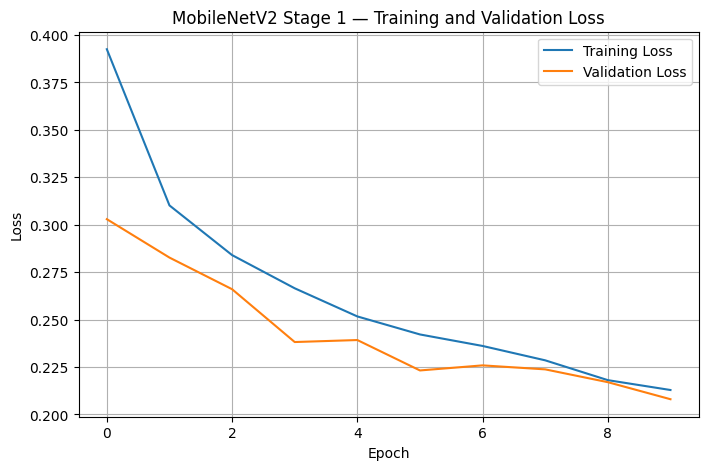

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    mobilenet_stage1_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    mobilenet_stage1_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "MobileNetV2 Stage 1 — Training and Validation Loss"
)

plt.legend()
plt.grid(True)

plt.show()

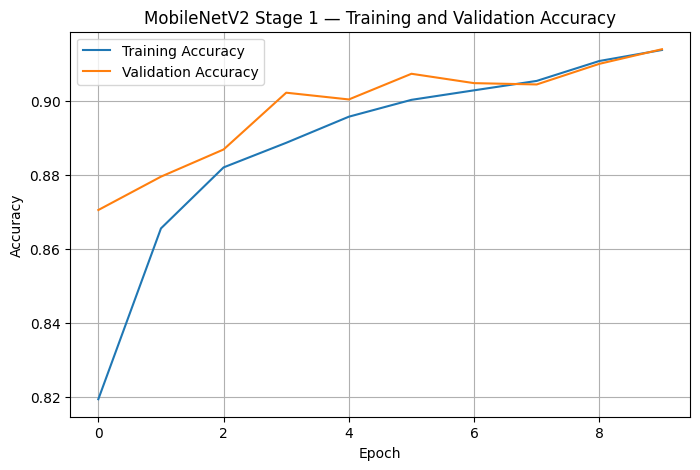

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    mobilenet_stage1_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    mobilenet_stage1_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "MobileNetV2 Stage 1 — Training and Validation Accuracy"
)

plt.legend()
plt.grid(True)

plt.show()

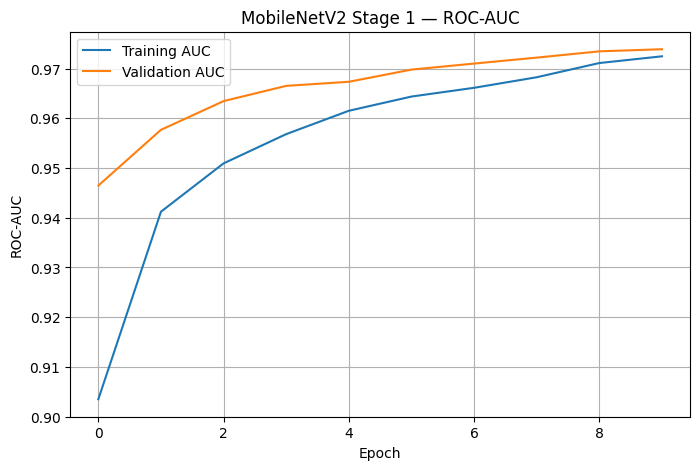

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    mobilenet_stage1_history.history["auc"],
    label="Training AUC"
)

plt.plot(
    mobilenet_stage1_history.history["val_auc"],
    label="Validation AUC"
)

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")

plt.title(
    "MobileNetV2 Stage 1 — ROC-AUC"
)

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
best_mobilenet_stage1 = tf.keras.models.load_model(
    mobilenet_stage1_path
)

print(
    "Best MobileNetV2 Stage 1 checkpoint loaded."
)

Best MobileNetV2 Stage 1 checkpoint loaded.


In [ ]:
mobilenet_stage1_results = (
    best_mobilenet_stage1.evaluate(
        validation_ds,
        return_dict=True,
        verbose=1
    )
)

print(
    "\nMobileNetV2 Stage 1 Validation Results:"
)

for metric, value in mobilenet_stage1_results.items():
    print(
        f"{metric}: {value:.4f}"
    )

617/617 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.9141 - auc: 0.9739 - loss: 0.2080 - precision: 0.9223 - recall: 0.9019

MobileNetV2 Stage 1 Validation Results:
accuracy: 0.9141
auc: 0.9739
loss: 0.2080
precision: 0.9223
recall: 0.9019


In [ ]:
mobilenet_base = best_mobilenet_stage1.get_layer(
    "mobilenetv2_1.00_224"
)

print("MobileNetV2 backbone found.")
print("Number of layers:", len(mobilenet_base.layers))

MobileNetV2 backbone found.
Number of layers: 154


In [ ]:
for i, layer in enumerate(mobilenet_base.layers):
    print(i, layer.name, type(layer).__name__)

0 input_layer_2 InputLayer
1 Conv1 Conv2D
2 bn_Conv1 BatchNormalization
3 Conv1_relu ReLU
4 expanded_conv_depthwise DepthwiseConv2D
5 expanded_conv_depthwise_BN BatchNormalization
6 expanded_conv_depthwise_relu ReLU
7 expanded_conv_project Conv2D
8 expanded_conv_project_BN BatchNormalization
9 block_1_expand Conv2D
10 block_1_expand_BN BatchNormalization
11 block_1_expand_relu ReLU
12 block_1_pad ZeroPadding2D
13 block_1_depthwise DepthwiseConv2D
14 block_1_depthwise_BN BatchNormalization
15 block_1_depthwise_relu ReLU
16 block_1_project Conv2D
17 block_1_project_BN BatchNormalization
18 block_2_expand Conv2D
19 block_2_expand_BN BatchNormalization
20 block_2_expand_relu ReLU
21 block_2_depthwise DepthwiseConv2D
22 block_2_depthwise_BN BatchNormalization
23 block_2_depthwise_relu ReLU
24 block_2_project Conv2D
25 block_2_project_BN BatchNormalization
26 block_2_add Add
27 block_3_expand Conv2D
28 block_3_expand_BN BatchNormalization
29 block_3_expand_relu ReLU
30 block_3_pad ZeroPaddin

In [ ]:
fine_tune_from = 100

mobilenet_base.trainable = True

for layer in mobilenet_base.layers[:fine_tune_from]:
    layer.trainable = False

for layer in mobilenet_base.layers[fine_tune_from:]:
    layer.trainable = True

In [ ]:
for layer in mobilenet_base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

In [ ]:
trainable_layers = [
    layer.name
    for layer in mobilenet_base.layers
    if layer.trainable
]

trainable_bn = [
    layer.name
    for layer in mobilenet_base.layers
    if isinstance(layer, tf.keras.layers.BatchNormalization)
    and layer.trainable
]

print("Total MobileNetV2 layers:", len(mobilenet_base.layers))
print("Trainable MobileNetV2 layers:", len(trainable_layers))
print("Trainable BatchNorm layers:", len(trainable_bn))
print("First 10 trainable layers:", trainable_layers[:10])

Total MobileNetV2 layers: 154
Trainable MobileNetV2 layers: 36
Trainable BatchNorm layers: 0
First 10 trainable layers: ['block_11_expand_relu', 'block_11_depthwise', 'block_11_depthwise_relu', 'block_11_project', 'block_11_add', 'block_12_expand', 'block_12_expand_relu', 'block_12_depthwise', 'block_12_depthwise_relu', 'block_12_project']


In [ ]:
total_params = best_mobilenet_stage1.count_params()

trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in best_mobilenet_stage1.trainable_weights
)

non_trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in best_mobilenet_stage1.non_trainable_weights
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)
print("Non-trainable parameters:", non_trainable_params)

Total parameters: 2586177
Trainable parameters: 2167809
Non-trainable parameters: 418368


In [ ]:
best_mobilenet_stage1.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss=tf.keras.losses.BinaryCrossentropy(),

    metrics=[

        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        ),

        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)

#### Fine Tuning MobileNet

In [ ]:
mobilenet_finetune_path = (
    "/kaggle/working/mobilenetv2_finetuned_best.keras"
)

mobilenet_finetune_callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=mobilenet_finetune_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
mobilenet_finetune_history = (
    best_mobilenet_stage1.fit(
        train_ds,
        validation_data=validation_ds,
        epochs=10,
        callbacks=mobilenet_finetune_callbacks,
        verbose=1
    )
)

Epoch 1/10
2468/2468 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.9173 - auc: 0.9736 - loss: 0.2068 - precision: 0.9175 - recall: 0.9143
Epoch 1: val_loss improved from None to 0.14505, saving model to /kaggle/working/mobilenetv2_finetuned_best.keras

Epoch 1: finished saving model to /kaggle/working/mobilenetv2_finetuned_best.keras
2468/2468 ━━━━━━━━━━━━━━━━━━━━ 560s 221ms/step - accuracy: 0.9262 - auc: 0.9785 - loss: 0.1867 - precision: 0.9265 - recall: 0.9236 - val_accuracy: 0.9426 - val_auc: 0.9878 - val_loss: 0.1451 - val_precision: 0.9585 - val_recall: 0.9236 - learning_rate: 1.0000e-05
Epoch 2/10
2468/2468 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.9432 - auc: 0.9871 - loss: 0.1432 - precision: 0.9436 - recall: 0.9411
Epoch 2: val_loss improved from 0.14505 to 0.12726, saving model to /kaggle/working/mobilenetv2_finetuned_best.keras

Epoch 2: finished saving model to /kaggle/working/mobilenetv2_finetuned_best.keras
2468/2468 ━━━━━━━━━━━━━━━━━━━━ 529s 214ms/step - accur

In [ ]:
mobilenet_finetune_history_df = pd.DataFrame(
    mobilenet_finetune_history.history
)

mobilenet_finetune_history_df

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
0,0.926191,0.978509,0.186746,0.926543,0.923642,0.942556,0.987761,0.145050,0.958453,0.923622,0.000010
1,0.945467,0.987900,0.138627,0.945311,0.944098,0.950053,0.990562,0.127263,0.966039,0.931527,0.000010
2,0.953737,0.990608,0.120563,0.954134,0.952003,0.955271,0.992525,0.112681,0.941575,0.969510,0.000010
3,0.958524,0.992336,0.108402,0.959114,0.956726,0.958715,0.993232,0.104386,0.963063,0.952880,0.000010
4,0.963602,0.994051,0.095203,0.964309,0.961834,0.950053,0.992406,0.129548,0.923725,0.979674,0.000010
5,0.966920,0.994936,0.086344,0.967632,0.965247,0.962616,0.993415,0.099518,0.959947,0.964480,0.000010
6,0.969922,0.995875,0.078180,0.970644,0.968327,0.965605,0.994723,0.094145,0.980081,0.949594,0.000010
7,0.971226,0.996387,0.073601,0.971254,0.970406,0.960134,0.994210,0.107471,0.938492,0.983677,0.000010
8,0.975279,0.996983,0.066483,0.975706,0.974154,0.962970,0.994617,0.095052,0.977528,0.946720,0.000010
9,0.980750,0.998137,0.051606,0.981581,0.979364,0.969758,0.994903,0.084405,0.975754,0.962632,0.000005


In [ ]:
best_mobilenet_ft_epoch = (
    mobilenet_finetune_history_df[
        "val_loss"
    ].idxmin() + 1
)

best_mobilenet_ft_loss = (
    mobilenet_finetune_history_df[
        "val_loss"
    ].min()
)

print(
    "Best fine-tuning epoch:",
    best_mobilenet_ft_epoch
)

print(
    "Best fine-tuning validation loss:",
    best_mobilenet_ft_loss
)

Best fine-tuning epoch: 10
Best fine-tuning validation loss: 0.08440489321947098


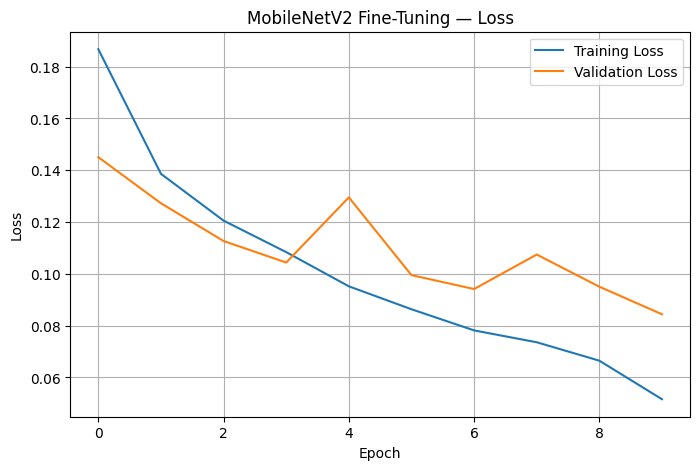

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    mobilenet_finetune_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    mobilenet_finetune_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "MobileNetV2 Fine-Tuning — Loss"
)

plt.legend()
plt.grid(True)

plt.show()

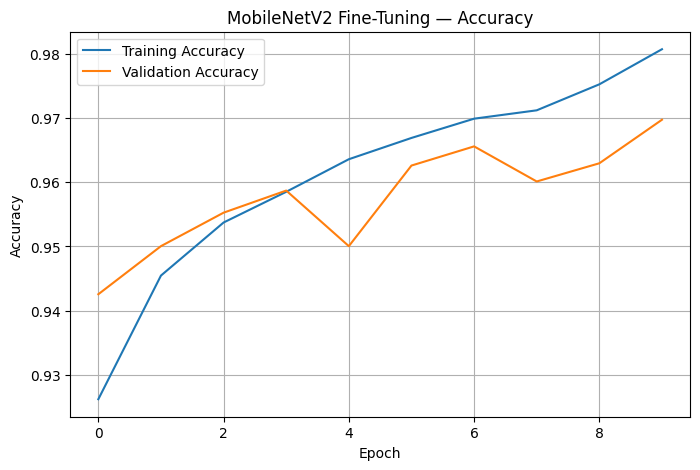

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    mobilenet_finetune_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    mobilenet_finetune_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "MobileNetV2 Fine-Tuning — Accuracy"
)

plt.legend()
plt.grid(True)

plt.show()

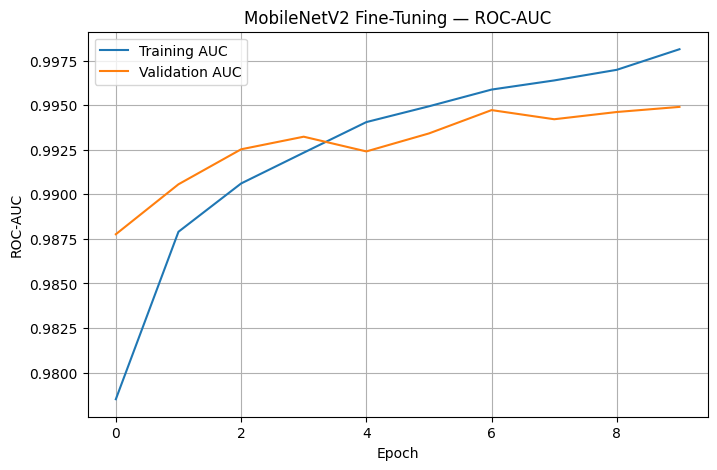

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    mobilenet_finetune_history.history["auc"],
    label="Training AUC"
)

plt.plot(
    mobilenet_finetune_history.history["val_auc"],
    label="Validation AUC"
)

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")

plt.title(
    "MobileNetV2 Fine-Tuning — ROC-AUC"
)

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
best_mobilenet = tf.keras.models.load_model(
    mobilenet_finetune_path
)

print(
    "Best MobileNetV2 fine-tuned model loaded."
)

Best MobileNetV2 fine-tuned model loaded.


In [ ]:
mobilenet_validation_results = (
    best_mobilenet.evaluate(
        validation_ds,
        return_dict=True,
        verbose=1
    )
)

print(
    "\nMobileNetV2 Fine-Tuned Validation Results:"
)

for metric, value in (
    mobilenet_validation_results.items()
):
    print(
        f"{metric}: {value:.4f}"
    )

617/617 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.9698 - auc: 0.9949 - loss: 0.0844 - precision: 0.9758 - recall: 0.9626

MobileNetV2 Fine-Tuned Validation Results:
accuracy: 0.9698
auc: 0.9949
loss: 0.0844
precision: 0.9758
recall: 0.9626


In [ ]:
mobilenet_probabilities = (
    best_mobilenet.predict(
        validation_ds,
        verbose=1
    ).ravel()
)

mobilenet_predictions = (
    mobilenet_probabilities >= 0.5
).astype(int)

617/617 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step


In [ ]:
mobilenet_true_labels = np.concatenate([
    labels.numpy()
    for _, labels in validation_ds
])

print(
    "True labels:",
    mobilenet_true_labels.shape
)

print(
    "Predictions:",
    mobilenet_predictions.shape
)

print(
    "Probabilities:",
    mobilenet_probabilities.shape
)

True labels: (19741,)
Predictions: (19741,)
Probabilities: (19741,)


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        mobilenet_true_labels,
        mobilenet_predictions,
        target_names=[
            "Real",
            "AI-Generated"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

        Real     0.9641    0.9767    0.9703     10000
AI-Generated     0.9758    0.9626    0.9691      9741

    accuracy                         0.9698     19741
   macro avg     0.9699    0.9697    0.9697     19741
weighted avg     0.9698    0.9698    0.9698     19741



[[9767  233]
 [ 364 9377]]


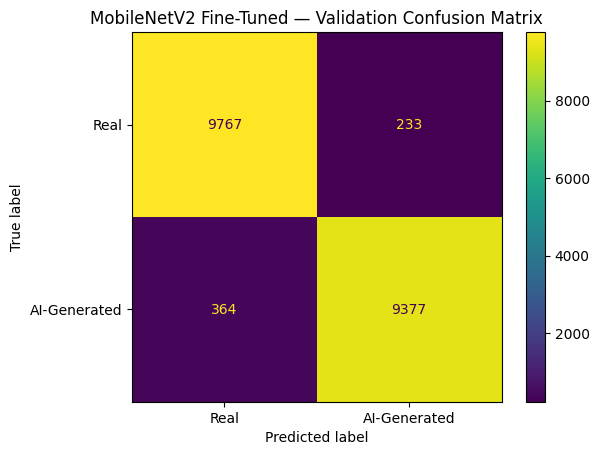

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

mobilenet_cm = confusion_matrix(
    mobilenet_true_labels,
    mobilenet_predictions
)

print(mobilenet_cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=mobilenet_cm,
    display_labels=[
        "Real",
        "AI-Generated"
    ]
)

disp.plot()

plt.title(
    "MobileNetV2 Fine-Tuned — Validation Confusion Matrix"
)

plt.show()

In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    roc_curve
)

mobilenet_auc = roc_auc_score(
    mobilenet_true_labels,
    mobilenet_probabilities
)

mobilenet_fpr, mobilenet_tpr, _ = roc_curve(
    mobilenet_true_labels,
    mobilenet_probabilities
)

print(
    "MobileNetV2 ROC-AUC:",
    round(mobilenet_auc, 4)
)

MobileNetV2 ROC-AUC: 0.996


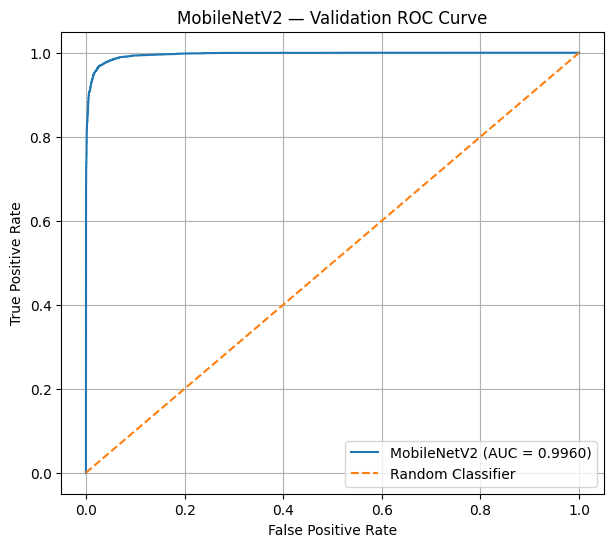

In [ ]:
plt.figure(figsize=(7, 6))

plt.plot(
    mobilenet_fpr,
    mobilenet_tpr,
    label=f"MobileNetV2 (AUC = {mobilenet_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "MobileNetV2 — Validation ROC Curve"
)

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

mobilenet_metrics = {

    "Model": "MobileNetV2 Fine-Tuned",

    "Accuracy": accuracy_score(
        mobilenet_true_labels,
        mobilenet_predictions
    ),

    "Precision": precision_score(
        mobilenet_true_labels,
        mobilenet_predictions
    ),

    "Recall": recall_score(
        mobilenet_true_labels,
        mobilenet_predictions
    ),

    "F1-Score": f1_score(
        mobilenet_true_labels,
        mobilenet_predictions
    ),

    "ROC-AUC": roc_auc_score(
        mobilenet_true_labels,
        mobilenet_probabilities
    ),

    "Loss": mobilenet_validation_results[
        "loss"
    ],

    "Best_Epoch": best_mobilenet_ft_epoch,

    "Total_Parameters": (
        best_mobilenet.count_params()
    )
}

mobilenet_metrics_df = pd.DataFrame(
    [mobilenet_metrics]
)

mobilenet_metrics_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Loss,Best_Epoch,Total_Parameters
0,MobileNetV2 Fine-Tuned,0.969758,0.975754,0.962632,0.969149,0.996047,0.084405,10,2586177


In [ ]:
from sklearn.metrics import roc_auc_score

mobilenet_final_auc = roc_auc_score(
    mobilenet_true_labels,
    mobilenet_probabilities
)

print(
    "Final MobileNetV2 ROC-AUC:",
    mobilenet_final_auc
)

Final MobileNetV2 ROC-AUC: 0.9960471922800533


### EfficientNet

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

print("EfficientNetB0 imported successfully.")

EfficientNetB0 imported successfully.


In [ ]:
efficientnet_base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

efficientnet_base.trainable = False

print("EfficientNetB0 backbone loaded.")
print("Trainable:", efficientnet_base.trainable)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0 backbone loaded.
Trainable: False


In [ ]:
efficientnet_model = tf.keras.Sequential([

    tf.keras.layers.Input(
        shape=(224, 224, 3),
        name="input_image"
    ),

    efficientnet_base,

    tf.keras.layers.GlobalAveragePooling2D(
        name="global_average_pooling"
    ),

    tf.keras.layers.Dropout(
        0.4,
        name="classifier_dropout"
    ),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid",
        name="output"
    )

], name="EfficientNetB0_TransferLearning")

In [ ]:
efficientnet_model.summary()

Model: "EfficientNetB0_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout (Dropout)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
total_params = efficientnet_model.count_params()

trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in efficientnet_model.trainable_weights
)

non_trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in efficientnet_model.non_trainable_weights
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)
print("Non-trainable parameters:", non_trainable_params)

Total parameters: 4050852
Trainable parameters: 1281
Non-trainable parameters: 4049571.0


In [ ]:
output_layer = efficientnet_model.get_layer("output")

print(
    "Output kernel shape:",
    output_layer.kernel.shape
)
output_layer.bias.assign(
    tf.zeros_like(output_layer.bias)
)
print(
    "Output bias:",
    output_layer.bias.numpy()
)


Output kernel shape: (1280, 1)
Output bias: [0.]


In [ ]:
efficientnet_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss=tf.keras.losses.BinaryCrossentropy(),

    metrics=[

        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        ),

        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)

In [ ]:
debug_ds = train_ds.take(20)

print("Debug batches:", 20)

Debug batches: 20


In [ ]:
debug_history = efficientnet_model.fit(
    debug_ds,
    epochs=1,
    verbose=1
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 158ms/step - accuracy: 0.5016 - auc: 0.4982 - loss: 0.7007 - precision: 0.4643 - recall: 0.2984


In [ ]:
debug_predictions = efficientnet_model.predict(
    sample_images,
    verbose=0
).ravel()

print(
    "Prediction min:",
    debug_predictions.min()
)

print(
    "Prediction max:",
    debug_predictions.max()
)

print(
    "Prediction mean:",
    debug_predictions.mean()
)

print(
    "Prediction std:",
    debug_predictions.std()
)

Prediction min: 0.4646885
Prediction max: 0.46558723
Prediction mean: 0.46515974
Prediction std: 0.00018776093


In [ ]:
debug_ds = train_ds.take(20)

debug_history = efficientnet_model.fit(
    debug_ds,
    epochs=1,
    verbose=1
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 210ms/step - accuracy: 0.5312 - auc: 0.5304 - loss: 0.6974 - precision: 0.5530 - recall: 0.3715


In [ ]:
debug_results = efficientnet_model.evaluate(
    debug_ds,
    return_dict=True,
    verbose=0
)

print("Debug results:")

for metric, value in debug_results.items():
    print(f"{metric}: {value:.4f}")

Debug results:
accuracy: 0.4938
auc: 0.5000
loss: 0.6936
precision: 0.0000
recall: 0.0000


In [ ]:
debug_predictions = efficientnet_model.predict(
    sample_images,
    verbose=0
).ravel()

print("Prediction min:", debug_predictions.min())
print("Prediction max:", debug_predictions.max())
print("Prediction mean:", debug_predictions.mean())
print("Prediction std:", debug_predictions.std())

Prediction min: 0.4890457
Prediction max: 0.489892
Prediction mean: 0.48948616
Prediction std: 0.00018379332


In [ ]:
efficientnet_test_path = (
    "/kaggle/working/efficientnetb0_serialization_test.keras"
)

efficientnet_model.save(
    efficientnet_test_path
)

print("EfficientNetB0 model saved successfully.")

EfficientNetB0 model saved successfully.


In [ ]:
efficientnet_test_loaded = tf.keras.models.load_model(
    efficientnet_test_path
)

print("EfficientNetB0 model loaded successfully.")

EfficientNetB0 model loaded successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
efficientnet_stage1_path = (
    "/kaggle/working/efficientnetb0_stage1_best.keras"
)

efficientnet_stage1_callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=efficientnet_stage1_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
efficientnet_stage1_history = (
    efficientnet_model.fit(
        train_ds,
        validation_data=validation_ds,
        epochs=10,
        callbacks=efficientnet_stage1_callbacks,
        verbose=1
    )
)

Epoch 1/10


2026-08-20 13:43:04.060425: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-20 13:43:04.203925: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-20 13:43:04.555348: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-20 13:43:04.697692: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-20 13:43:05.517188: E external/local_xla/xla/stream_

2467/2468 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.4961 - auc: 0.4979 - loss: 0.6991 - precision: 0.4866 - recall: 0.4400

2026-08-20 13:51:51.398349: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-20 13:51:51.538866: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-20 13:51:51.870084: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-20 13:51:52.012008: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-20 13:51:52.890211: E external/local_xla/xla/stream_

2468/2468 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.4961 - auc: 0.4979 - loss: 0.6991 - precision: 0.4866 - recall: 0.4400

2026-08-20 13:52:33.834325: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-20 13:52:33.978064: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-20 13:52:34.334927: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-20 13:52:34.476704: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-20 13:52:35.287729: E external/local_xla/xla/stream_


Epoch 1: val_loss improved from None to 0.69365, saving model to /kaggle/working/efficientnetb0_stage1_best.keras

Epoch 1: finished saving model to /kaggle/working/efficientnetb0_stage1_best.keras
2468/2468 ━━━━━━━━━━━━━━━━━━━━ 596s 230ms/step - accuracy: 0.4979 - auc: 0.5002 - loss: 0.6983 - precision: 0.4904 - recall: 0.4461 - val_accuracy: 0.4934 - val_auc: 0.5000 - val_loss: 0.6937 - val_precision: 0.4934 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/10
2468/2468 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.5012 - auc: 0.5014 - loss: 0.6973 - precision: 0.4940 - recall: 0.4552
Epoch 2: val_loss improved from 0.69365 to 0.69314, saving model to /kaggle/working/efficientnetb0_stage1_best.keras

Epoch 2: finished saving model to /kaggle/working/efficientnetb0_stage1_best.keras
2468/2468 ━━━━━━━━━━━━━━━━━━━━ 535s 217ms/step - accuracy: 0.5013 - auc: 0.5017 - loss: 0.6971 - precision: 0.4941 - recall: 0.4471 - val_accuracy: 0.5066 - val_auc: 0.5000 - val_loss: 0.6931 - 

In [ ]:
print("EfficientNet base trainable:",
      efficientnet_base.trainable)

print("Model input shape:",
      efficientnet_model.input_shape)

print("Model output shape:",
      efficientnet_model.output_shape)

EfficientNet base trainable: False
Model input shape: (None, 224, 224, 3)
Model output shape: (None, 1)


In [ ]:
efficientnet_model.summary()

Model: "EfficientNetB0_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dense (Dense)        │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout (Dropout)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,034,152 (19.20 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 656,388 (2.50 MB)

In [ ]:
efficientnet_base = efficientnet_model.layers[0]

print(
    "First layer:",
    efficientnet_base.name
)

First layer: efficientnetb0


In [ ]:
sample_images, sample_labels = next(
    iter(validation_ds)
)

print("Input shape:", sample_images.shape)
print("Input dtype:", sample_images.dtype)

print(
    "Input range:",
    float(tf.reduce_min(sample_images)),
    float(tf.reduce_max(sample_images))
)

print(
    "Labels:",
    sample_labels.numpy()
)

print(
    "Unique labels:",
    np.unique(sample_labels.numpy())
)

print(
    "Label counts:",
    np.bincount(
        sample_labels.numpy().astype(int)
    )
)

Input shape: (32, 224, 224, 3)
Input dtype: <dtype: 'float32'>
Input range: 0.0 1.0
Labels: [1 1 0 1 0 0 1 0 0 1 1 1 0 1 0 1 0 1 1 1 1 1 0 0 1 1 0 1 0 1 1 0]
Unique labels: [0 1]
Label counts: [13 19]


In [ ]:
features = efficientnet_base(
    sample_images,
    training=False
)

print("Feature shape:", features.shape)

print(
    "Feature minimum:",
    float(tf.reduce_min(features))
)

print(
    "Feature maximum:",
    float(tf.reduce_max(features))
)

print(
    "Feature mean:",
    float(tf.reduce_mean(features))
)

print(
    "Feature std:",
    float(tf.math.reduce_std(features))
)

Feature shape: (32, 7, 7, 1280)
Feature minimum: -0.27846458554267883
Feature maximum: 9.617499351501465
Feature mean: -0.1048436388373375
Feature std: 0.4590971767902374


In [ ]:
initial_predictions = efficientnet_model.predict(
    sample_images,
    verbose=0
).ravel()

print("Predictions:")
print(initial_predictions)

print(
    "Prediction min:",
    initial_predictions.min()
)

print(
    "Prediction max:",
    initial_predictions.max()
)

print(
    "Prediction mean:",
    initial_predictions.mean()
)

print(
    "Prediction std:",
    initial_predictions.std()
)

Predictions:
[0.49304184 0.49304995 0.4930162  0.4930013  0.49296895 0.49302486
 0.4930627  0.49304426 0.49306607 0.49301064 0.49308822 0.49305448
 0.4930597  0.4930504  0.4930201  0.49301216 0.4929942  0.49303824
 0.4930545  0.49305645 0.4930678  0.49299246 0.49306884 0.49303645
 0.49306083 0.49300265 0.49303615 0.4931103  0.49305063 0.49306896
 0.49310425 0.4930154 ]
Prediction min: 0.49296895
Prediction max: 0.4931103
Prediction mean: 0.49304157
Prediction std: 3.1904387e-05


In [ ]:
print(
    "EfficientNet weights:",
    len(efficientnet_base.get_weights())
)

EfficientNet weights: 312


In [ ]:
for i, weights in enumerate(
    efficientnet_base.get_weights()[:5]
):
    print(
        i,
        weights.shape,
        weights.min(),
        weights.max()
    )

0 (3,) 0.406 0.485
1 (3,) 0.224 0.229
2 () 0 0
3 (3, 3, 3, 32) -4.200738 4.153637
4 (32,) 0.20251513 11.991241


In [ ]:
classifier_dense = efficientnet_model.get_layer(
    "classifier_dense"
)

output_layer = efficientnet_model.get_layer(
    "output"
)

print(
    "Classifier Dense weights:",
    classifier_dense.get_weights()[0].shape
)

print(
    "Classifier Dense bias:",
    classifier_dense.get_weights()[1].shape
)

print(
    "Output weights:",
    output_layer.get_weights()[0].shape
)

print(
    "Output bias:",
    output_layer.get_weights()[1].shape
)

Classifier Dense weights: (1280, 256)
Classifier Dense bias: (256,)
Output weights: (256, 1)
Output bias: (1,)
